In [1]:
import sys
print(sys.executable)

c:\Users\sayeem\AppData\Local\Programs\Python\Python310\python.exe


# Model Experiments on Balanced Normalized Data (n = 1918)

This notebook runs all classification models on the GAN-augmented balanced normalized dataset.

**Update (Reviewer Revision):** Added **5-Fold Stratified Cross-Validation** for every model, in addition to the original 80/20 single train-test split, to address the reviewer comment on validation protocol.

> **Note:** CTGAN augmentation was still applied on the *full* dataset before this split/CV (as in the original manuscript). The reviewer separately flagged this as a potential leakage issue ("CTGAN can be applied ONLY on Training Set"). That fix is deferred to a follow-up revision and is NOT included in this notebook yet.

## Models:
1. Random Forest Classifier
2. Gradient Boosting Classifier
3. XGBoost Classifier
4. CatBoost Classifier
5. Logistic Regression
6. Artificial Neural Network (PyTorch)

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Train-Test Split and Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, roc_auc_score
)

# NEW: Cross-Validation tools
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("All libraries imported successfully!")

Using device: cpu
All libraries imported successfully!


## 2. Load Balanced Normalized Data

In [3]:
# Load the GAN-augmented balanced normalized data
df = pd.read_csv(r'../data/Final_Combined_Normalized.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (1918, 31)

Columns: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


,Age,Gender,Where_live,AVG_Sleep_Per_Night,Regular_Bed_time,Exam_Night_Bed_Time,Holiday_Bed_Time,Regular_WakeUp_Time,Holiday_WakeUp_Time,Have_Regular_Bed_Time,...,Class_Attendance,Sleepiness_During_Class,Skip_Class_for_Sleep,Focus_on_Academic_Task,Impact_of_Sleep_on_Academic,Current_CGPA5,CGPA3_Class,Aware_of_Recomamended_Sleep,Use_Sleep_Tracking_Devices,Sacrifices_Sleep_for_Academics
0,0.666667,1.0,0.0,1.000000,1.00,1.00,1.00,1.0,1.0,0.0,...,0.333333,0.666667,0.0,0.0,0.75,0.50,0.5,1.0,0.0,1.0
1,0.666667,0.0,0.5,0.333333,0.75,0.25,0.25,0.5,1.0,0.0,...,0.333333,0.000000,1.0,0.5,0.75,0.75,0.5,1.0,0.0,1.0
2,0.666667,0.0,0.5,0.000000,1.00,1.00,1.00,0.5,1.0,0.0,...,0.000000,0.000000,1.0,0.0,0.00,0.75,0.5,1.0,0.0,1.0
3,1.000000,0.0,0.5,0.666667,0.50,0.75,1.00,0.5,1.0,0.0,...,0.000000,0.000000,0.0,1.0,0.25,0.75,0.5,1.0,0.0,1.0
4,0.666667,0.0,0.0,0.333333,0.75,0.75,0.75,0.5,0.5,0.0,...,1.000000,0.333333,0.0,0.5,0.25,0.75,0.5,0.0,0.0,1.0


In [4]:
# Check class distribution
TARGET_COLUMN = 'CGPA3_Class'

print("Class Distribution (Normalized Values):")
print(df[TARGET_COLUMN].value_counts().sort_index())

# Convert normalized target back to integer classes for modeling
# 0.0 -> 0, 0.5 -> 1, 1.0 -> 2
df['Target'] = (df[TARGET_COLUMN] * 2).round().astype(int)

print("\nConverted Target Classes:")
print(df['Target'].value_counts().sort_index())
print("\n0 = CGPA 3.5-4.0 (High)")
print("1 = CGPA 3.0-3.49 (Average)")
print("2 = CGPA <3.0 (Low)")

Class Distribution (Normalized Values):
CGPA3_Class
0.0    655
0.5    608
1.0    655
Name: count, dtype: int64

Converted Target Classes:
Target
0    655
1    608
2    655
Name: count, dtype: int64

0 = CGPA 3.5-4.0 (High)
1 = CGPA 3.0-3.49 (Average)
2 = CGPA <3.0 (Low)


## 3. Prepare Features and Target

In [5]:
# Define features (exclude target columns)
exclude_cols = ['CGPA3_Class', 'Target', 'Current_CGPA5']  # Exclude target and related columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 29
Features: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


In [6]:
# Prepare X and y
X = df[feature_cols].values
y = df['Target'].values

# Train-Test Split (80-20) -- kept as the ORIGINAL single-split evaluation,
# reported alongside the new 5-fold CV results for direct comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_test)*100:.1f}%)")

Training set: 1534 samples
Test set: 384 samples

Training class distribution:
  Class 0: 524 (34.2%)
  Class 1: 486 (31.7%)
  Class 2: 524 (34.2%)

Test class distribution:
  Class 0: 131 (34.1%)
  Class 1: 122 (31.8%)
  Class 2: 131 (34.1%)


## 4. Helper Functions

In [7]:
# Store all single-split results
all_results = []

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a fitted model on the single 80/20 test split and return metrics.
    """
    y_pred = model.predict(X_test)

    # For models that support predict_proba
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    except:
        roc_auc = None

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    result = {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Balanced Accuracy': round(balanced_acc, 4),
        'ROC-AUC': round(roc_auc, 4) if roc_auc else 'N/A'
    }

    all_results.append(result)
    return result, y_pred

def plot_confusion_matrix(y_test, y_pred, model_name):
    """
    Plot confusion matrix (inline only -- not saved to disk).
    """
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)'],
                yticklabels=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_test, y_pred, model_name):
    """
    Print classification report
    """
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print('='*60)
    print(classification_report(y_test, y_pred,
          target_names=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']))

## 4b. 5-Fold Stratified Cross-Validation Setup (NEW)

Addresses reviewer comment #1 (*"no repeated validation such as 5-fold CV... a single split can produce optimistic or unstable performance estimates"*).

This cell only needs to be defined **once**, here, before any model is trained. Every model cell below then adds a **single extra line** — `evaluate_model_cv(model, "Model Name", X, y)` — right after the model is defined, and it will automatically run 5-fold CV and log the results to a shared `cv_results` table. No other changes are needed per model.

**Caveat (to be fixed in a later revision):** this CV still runs on `X`, `y` from the full CTGAN-augmented dataset, so it does not yet resolve the separate CTGAN-leakage concern (reviewer comment #2). It DOES, however, fully resolve comment #1 by replacing the single-split estimate with a mean ± std across 5 independent folds.

In [8]:
# 5-Fold Stratified Cross-Validation setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store CV results for every model here
cv_results = []

def evaluate_model_cv(model, model_name, X, y, cv=cv_strategy):
    """
    Run 5-fold Stratified CV for a given (already-defined, unfitted-is-fine) 
    scikit-learn-compatible model. A FRESH clone of the model is trained on 
    each fold internally (via cross_validate), so this does NOT reuse the 
    single-split fit -- it is a fully independent robustness check.

    Call this ONCE per model, right after the model object is created 
    (order relative to model.fit(X_train, y_train) does not matter).

    Automatically appends mean +/- std metrics to the shared cv_results list.
    """
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'balanced_accuracy': 'balanced_accuracy',
        'roc_auc_ovr': 'roc_auc_ovr'
    }

    scores = cross_validate(
        clone(model), X, y,
        cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )

    result = {
        'Model': model_name,
        'CV Accuracy (mean)': round(scores['test_accuracy'].mean(), 4),
        'CV Accuracy (std)': round(scores['test_accuracy'].std(), 4),
        'CV Macro F1 (mean)': round(scores['test_f1_macro'].mean(), 4),
        'CV Macro F1 (std)': round(scores['test_f1_macro'].std(), 4),
        'CV Balanced Acc (mean)': round(scores['test_balanced_accuracy'].mean(), 4),
        'CV Balanced Acc (std)': round(scores['test_balanced_accuracy'].std(), 4),
        'CV ROC-AUC (mean)': round(scores['test_roc_auc_ovr'].mean(), 4),
        'CV ROC-AUC (std)': round(scores['test_roc_auc_ovr'].std(), 4),
    }

    cv_results.append(result)

    print(f"\n5-Fold CV Results -- {model_name}")
    print(f"  Accuracy:          {result['CV Accuracy (mean)']:.4f} +/- {result['CV Accuracy (std)']:.4f}")
    print(f"  Macro F1-Score:    {result['CV Macro F1 (mean)']:.4f} +/- {result['CV Macro F1 (std)']:.4f}")
    print(f"  Balanced Accuracy: {result['CV Balanced Acc (mean)']:.4f} +/- {result['CV Balanced Acc (std)']:.4f}")
    print(f"  ROC-AUC:           {result['CV ROC-AUC (mean)']:.4f} +/- {result['CV ROC-AUC (std)']:.4f}")

    return result

print("5-Fold Stratified CV is ready.")
print("From here on, every sklearn-compatible model cell just adds ONE line:")
print("  evaluate_model_cv(<model_object>, '<Model Name>', X, y)")

5-Fold Stratified CV is ready.
From here on, every sklearn-compatible model cell just adds ONE line:
  evaluate_model_cv(<model_object>, '<Model Name>', X, y)


---
## 5. Model 1: Random Forest Classifier

In [9]:
print("Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
result, y_pred_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation (one extra line -- everything else is unchanged)
evaluate_model_cv(rf_model, 'Random Forest', X, y)

Training Random Forest Classifier...

Results (Single 80/20 Split):
  Model: Random Forest
  Accuracy: 0.5938
  Macro F1-Score: 0.5911
  Balanced Accuracy: 0.589
  ROC-AUC: 0.7848

5-Fold CV Results -- Random Forest
  Accuracy:          0.5907 +/- 0.0184
  Macro F1-Score:    0.5906 +/- 0.0204
  Balanced Accuracy: 0.5859 +/- 0.0187
  ROC-AUC:           0.7833 +/- 0.0055


{'Model': 'Random Forest',
 'CV Accuracy (mean)': np.float64(0.5907),
 'CV Accuracy (std)': np.float64(0.0184),
 'CV Macro F1 (mean)': np.float64(0.5906),
 'CV Macro F1 (std)': np.float64(0.0204),
 'CV Balanced Acc (mean)': np.float64(0.5859),
 'CV Balanced Acc (std)': np.float64(0.0187),
 'CV ROC-AUC (mean)': np.float64(0.7833),
 'CV ROC-AUC (std)': np.float64(0.0055)}

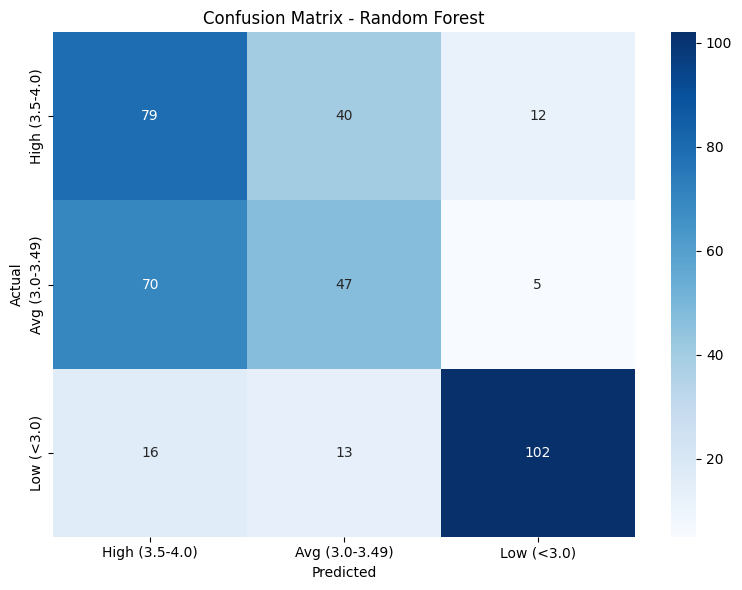


Classification Report - Random Forest
                precision    recall  f1-score   support

High (3.5-4.0)       0.48      0.60      0.53       131
Avg (3.0-3.49)       0.47      0.39      0.42       122
    Low (<3.0)       0.86      0.78      0.82       131

      accuracy                           0.59       384
     macro avg       0.60      0.59      0.59       384
  weighted avg       0.61      0.59      0.59       384



In [10]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print_classification_report(y_test, y_pred_rf, 'Random Forest')

---
## 6. Model 2: Gradient Boosting Classifier

In [11]:
print("Training Gradient Boosting Classifier...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,          # 100 -> 300
    max_depth=6,               # 5 -> 6
    learning_rate=0.05,        # 0.1 -> 0.05
    min_samples_split=5,       # NEW (default is 2)
    min_samples_leaf=3,        # NEW (default is 1)
    subsample=0.8,             # NEW (stochastic GB)
    max_features='sqrt',       # NEW (feature sampling)
    validation_fraction=0.1,   # NEW (early stopping data)
    n_iter_no_change=20,       # NEW (early stopping patience)
    random_state=42
)

gb_model.fit(X_train, y_train)
result, y_pred_gb = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(gb_model, 'Gradient Boosting', X, y)

Training Gradient Boosting Classifier...

Results (Single 80/20 Split):
  Model: Gradient Boosting
  Accuracy: 0.6302
  Macro F1-Score: 0.6258
  Balanced Accuracy: 0.6261
  ROC-AUC: 0.7974

5-Fold CV Results -- Gradient Boosting
  Accuracy:          0.6069 +/- 0.0129
  Macro F1-Score:    0.6076 +/- 0.0135
  Balanced Accuracy: 0.6029 +/- 0.0129
  ROC-AUC:           0.7853 +/- 0.0053


{'Model': 'Gradient Boosting',
 'CV Accuracy (mean)': np.float64(0.6069),
 'CV Accuracy (std)': np.float64(0.0129),
 'CV Macro F1 (mean)': np.float64(0.6076),
 'CV Macro F1 (std)': np.float64(0.0135),
 'CV Balanced Acc (mean)': np.float64(0.6029),
 'CV Balanced Acc (std)': np.float64(0.0129),
 'CV ROC-AUC (mean)': np.float64(0.7853),
 'CV ROC-AUC (std)': np.float64(0.0053)}

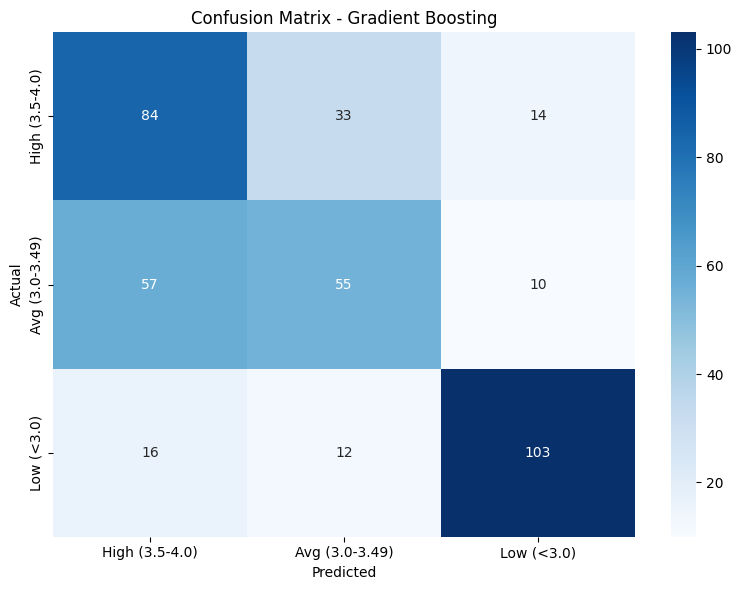


Classification Report - Gradient Boosting
                precision    recall  f1-score   support

High (3.5-4.0)       0.54      0.64      0.58       131
Avg (3.0-3.49)       0.55      0.45      0.50       122
    Low (<3.0)       0.81      0.79      0.80       131

      accuracy                           0.63       384
     macro avg       0.63      0.63      0.63       384
  weighted avg       0.63      0.63      0.63       384



In [12]:
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosting')
print_classification_report(y_test, y_pred_gb, 'Gradient Boosting')

---
## 7. Model 3: XGBoost Classifier

In [13]:
print("Training XGBoost Classifier...")

xgb_model = XGBClassifier(
    n_estimators=300,        # 100 -> 300
    max_depth=6,             # 5 -> 6
    learning_rate=0.05,      # 0.1 -> 0.05
    min_child_weight=3,      # NEW (prevent overfitting)
    subsample=0.8,           # NEW (row sampling)
    colsample_bytree=0.8,    # NEW (column sampling)
    gamma=1,                 # NEW (min loss reduction)
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
result, y_pred_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(xgb_model, 'XGBoost', X, y)

Training XGBoost Classifier...

Results (Single 80/20 Split):
  Model: XGBoost
  Accuracy: 0.6328
  Macro F1-Score: 0.6314
  Balanced Accuracy: 0.629
  ROC-AUC: 0.7921

5-Fold CV Results -- XGBoost
  Accuracy:          0.5954 +/- 0.0147
  Macro F1-Score:    0.5978 +/- 0.0159
  Balanced Accuracy: 0.5917 +/- 0.0153
  ROC-AUC:           0.7876 +/- 0.0114


{'Model': 'XGBoost',
 'CV Accuracy (mean)': np.float64(0.5954),
 'CV Accuracy (std)': np.float64(0.0147),
 'CV Macro F1 (mean)': np.float64(0.5978),
 'CV Macro F1 (std)': np.float64(0.0159),
 'CV Balanced Acc (mean)': np.float64(0.5917),
 'CV Balanced Acc (std)': np.float64(0.0153),
 'CV ROC-AUC (mean)': np.float64(0.7876),
 'CV ROC-AUC (std)': np.float64(0.0114)}

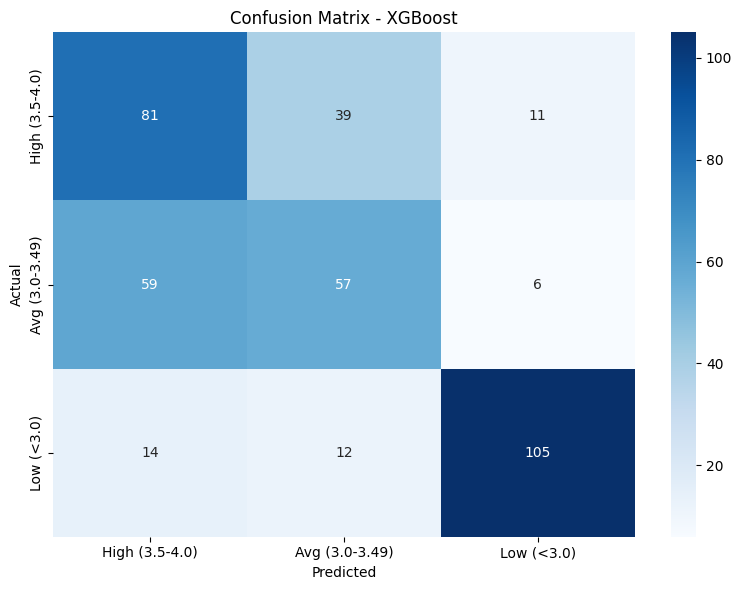


Classification Report - XGBoost
                precision    recall  f1-score   support

High (3.5-4.0)       0.53      0.62      0.57       131
Avg (3.0-3.49)       0.53      0.47      0.50       122
    Low (<3.0)       0.86      0.80      0.83       131

      accuracy                           0.63       384
     macro avg       0.64      0.63      0.63       384
  weighted avg       0.64      0.63      0.63       384



In [14]:
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')
print_classification_report(y_test, y_pred_xgb, 'XGBoost')

---
## 8. Model 4: CatBoost Classifier

In [15]:
print("Training CatBoost Classifier...")

catboost_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
result, y_pred_cat = evaluate_model(catboost_model, X_test, y_test, 'CatBoost')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(catboost_model, 'CatBoost', X, y)

Training CatBoost Classifier...

Results (Single 80/20 Split):
  Model: CatBoost
  Accuracy: 0.6042
  Macro F1-Score: 0.5922
  Balanced Accuracy: 0.5984
  ROC-AUC: 0.7832

5-Fold CV Results -- CatBoost
  Accuracy:          0.5829 +/- 0.0032
  Macro F1-Score:    0.5788 +/- 0.0065
  Balanced Accuracy: 0.5784 +/- 0.0034
  ROC-AUC:           0.7801 +/- 0.0065


{'Model': 'CatBoost',
 'CV Accuracy (mean)': np.float64(0.5829),
 'CV Accuracy (std)': np.float64(0.0032),
 'CV Macro F1 (mean)': np.float64(0.5788),
 'CV Macro F1 (std)': np.float64(0.0065),
 'CV Balanced Acc (mean)': np.float64(0.5784),
 'CV Balanced Acc (std)': np.float64(0.0034),
 'CV ROC-AUC (mean)': np.float64(0.7801),
 'CV ROC-AUC (std)': np.float64(0.0065)}

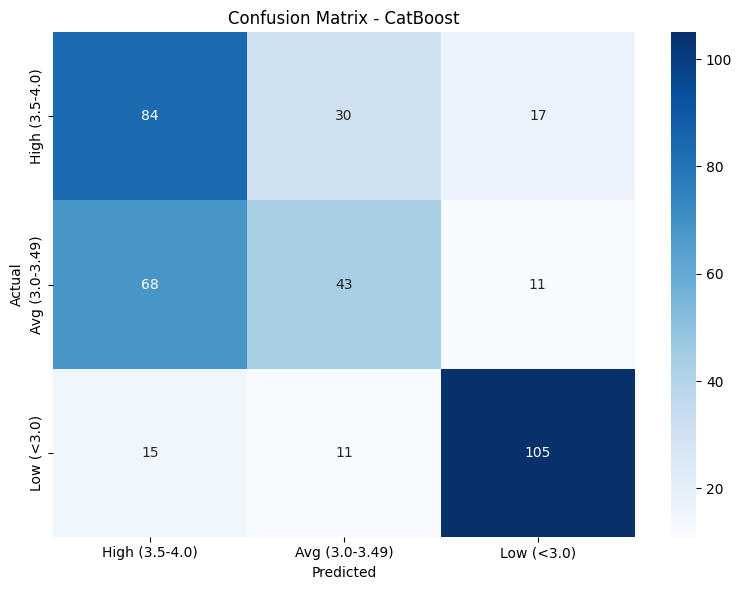


Classification Report - CatBoost
                precision    recall  f1-score   support

High (3.5-4.0)       0.50      0.64      0.56       131
Avg (3.0-3.49)       0.51      0.35      0.42       122
    Low (<3.0)       0.79      0.80      0.80       131

      accuracy                           0.60       384
     macro avg       0.60      0.60      0.59       384
  weighted avg       0.60      0.60      0.60       384



In [16]:
plot_confusion_matrix(y_test, y_pred_cat, 'CatBoost')
print_classification_report(y_test, y_pred_cat, 'CatBoost')

---
## 9. Model 5: Logistic Regression

In [17]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=2000,             # 1000 -> 2000
    C=0.5,                     # NEW (less regularization, default is 1.0)
    penalty='elasticnet',      # NEW (L1 + L2 combined)
    solver='saga',             # lbfgs -> saga (supports elasticnet)
    l1_ratio=0.5,              # NEW (balance between L1 and L2)
    multi_class='multinomial',
    class_weight='balanced',   # NEW (handle class imbalance)
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
result, y_pred_lr = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

print(f"\nResults (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation
evaluate_model_cv(lr_model, 'Logistic Regression', X, y)

Training Logistic Regression...

Results (Single 80/20 Split):
  Model: Logistic Regression
  Accuracy: 0.5573
  Macro F1-Score: 0.5507
  Balanced Accuracy: 0.5541
  ROC-AUC: 0.7397

5-Fold CV Results -- Logistic Regression
  Accuracy:          0.5313 +/- 0.0186
  Macro F1-Score:    0.5220 +/- 0.0207
  Balanced Accuracy: 0.5286 +/- 0.0186
  ROC-AUC:           0.7335 +/- 0.0174


{'Model': 'Logistic Regression',
 'CV Accuracy (mean)': np.float64(0.5313),
 'CV Accuracy (std)': np.float64(0.0186),
 'CV Macro F1 (mean)': np.float64(0.522),
 'CV Macro F1 (std)': np.float64(0.0207),
 'CV Balanced Acc (mean)': np.float64(0.5286),
 'CV Balanced Acc (std)': np.float64(0.0186),
 'CV ROC-AUC (mean)': np.float64(0.7335),
 'CV ROC-AUC (std)': np.float64(0.0174)}

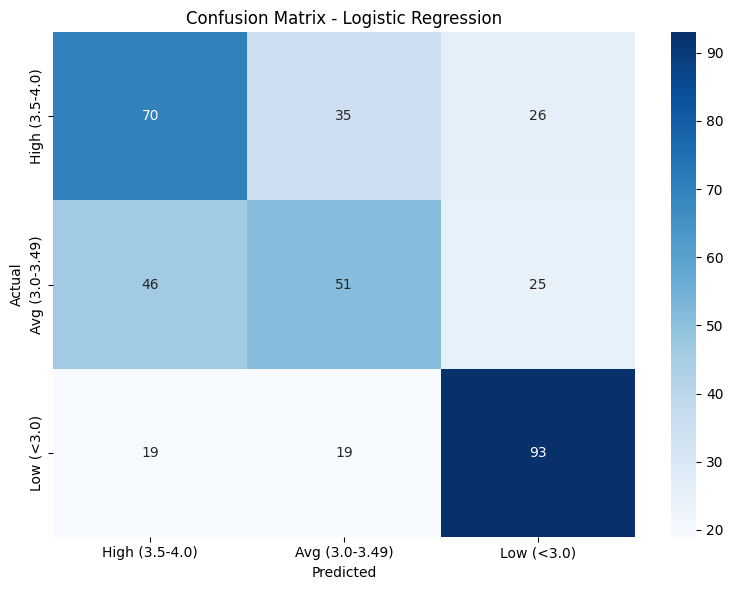


Classification Report - Logistic Regression
                precision    recall  f1-score   support

High (3.5-4.0)       0.52      0.53      0.53       131
Avg (3.0-3.49)       0.49      0.42      0.45       122
    Low (<3.0)       0.65      0.71      0.68       131

      accuracy                           0.56       384
     macro avg       0.55      0.55      0.55       384
  weighted avg       0.55      0.56      0.55       384



In [18]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
print_classification_report(y_test, y_pred_lr, 'Logistic Regression')

---
## 10. Model 6: Artificial Neural Network (PyTorch)

**Note:** PyTorch models are not scikit-learn compatible, so `evaluate_model_cv` (which relies on `clone()` + `cross_validate`) cannot be reused as-is here. A small dedicated CV helper, `evaluate_ann_cv`, is defined below instead -- same idea (5-fold, fresh model per fold, logs into the same shared `cv_results` list), just adapted for a manual PyTorch training loop.

In [19]:
# Define Neural Network Architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(NeuralNetwork, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

print("Neural Network class defined.")

Neural Network class defined.


In [20]:
# NEW: 5-Fold CV helper for the PyTorch ANN
def evaluate_ann_cv(X, y, cv=cv_strategy, hidden_sizes=[128, 64, 32],
                     epochs=100, batch_size=32, lr=0.001):
    """
    Manual 5-fold Stratified CV for the PyTorch ANN. A FRESH NeuralNetwork
    instance is trained from scratch on each fold's training portion and
    evaluated on that fold's held-out portion. Results are appended to the
    same shared cv_results list used by the other models.
    """
    fold_accuracies, fold_f1s, fold_bals, fold_aucs = [], [], [], []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        X_tr_t = torch.FloatTensor(X_tr).to(device)
        y_tr_t = torch.LongTensor(y_tr).to(device)
        X_val_t = torch.FloatTensor(X_val).to(device)

        fold_train_ds = TensorDataset(X_tr_t, y_tr_t)
        fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True)

        fold_model = NeuralNetwork(X.shape[1], hidden_sizes, num_classes=3).to(device)
        fold_criterion = nn.CrossEntropyLoss()
        fold_optimizer = optim.Adam(fold_model.parameters(), lr=lr)

        fold_model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in fold_train_loader:
                fold_optimizer.zero_grad()
                outputs = fold_model(batch_X)
                loss = fold_criterion(outputs, batch_y)
                loss.backward()
                fold_optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            outputs = fold_model(X_val_t)
            _, y_pred_fold = torch.max(outputs, 1)
            y_pred_fold = y_pred_fold.cpu().numpy()
            y_prob_fold = torch.softmax(outputs, dim=1).cpu().numpy()

        fold_accuracies.append(accuracy_score(y_val, y_pred_fold))
        fold_f1s.append(f1_score(y_val, y_pred_fold, average='macro'))
        fold_bals.append(balanced_accuracy_score(y_val, y_pred_fold))
        fold_aucs.append(roc_auc_score(y_val, y_prob_fold, multi_class='ovr', average='macro'))

        print(f"  Fold {fold_idx}/5 done -- Accuracy: {fold_accuracies[-1]:.4f}")

    result = {
        'Model': 'Neural Network',
        'CV Accuracy (mean)': round(float(np.mean(fold_accuracies)), 4),
        'CV Accuracy (std)': round(float(np.std(fold_accuracies)), 4),
        'CV Macro F1 (mean)': round(float(np.mean(fold_f1s)), 4),
        'CV Macro F1 (std)': round(float(np.std(fold_f1s)), 4),
        'CV Balanced Acc (mean)': round(float(np.mean(fold_bals)), 4),
        'CV Balanced Acc (std)': round(float(np.std(fold_bals)), 4),
        'CV ROC-AUC (mean)': round(float(np.mean(fold_aucs)), 4),
        'CV ROC-AUC (std)': round(float(np.std(fold_aucs)), 4),
    }
    cv_results.append(result)

    print(f"\n5-Fold CV Results -- Neural Network")
    print(f"  Accuracy:          {result['CV Accuracy (mean)']:.4f} +/- {result['CV Accuracy (std)']:.4f}")
    print(f"  Macro F1-Score:    {result['CV Macro F1 (mean)']:.4f} +/- {result['CV Macro F1 (std)']:.4f}")
    print(f"  Balanced Accuracy: {result['CV Balanced Acc (mean)']:.4f} +/- {result['CV Balanced Acc (std)']:.4f}")
    print(f"  ROC-AUC:           {result['CV ROC-AUC (mean)']:.4f} +/- {result['CV ROC-AUC (std)']:.4f}")

    return result

print("evaluate_ann_cv() ready.")

evaluate_ann_cv() ready.


In [21]:
# Prepare data for PyTorch (single 80/20 split)
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]
num_classes = 3

ann_model = NeuralNetwork(input_size, hidden_sizes, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

print(f"Model architecture:")
print(ann_model)

Model architecture:
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [22]:
# Training loop (single 80/20 split)
print("Training Neural Network...")
epochs = 100
train_losses = []

for epoch in range(epochs):
    ann_model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ann_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}")

print("\nTraining completed!")

Training Neural Network...
Epoch [20/100], Loss: 0.8157
Epoch [40/100], Loss: 0.7206
Epoch [60/100], Loss: 0.6461
Epoch [80/100], Loss: 0.5793
Epoch [100/100], Loss: 0.5400

Training completed!


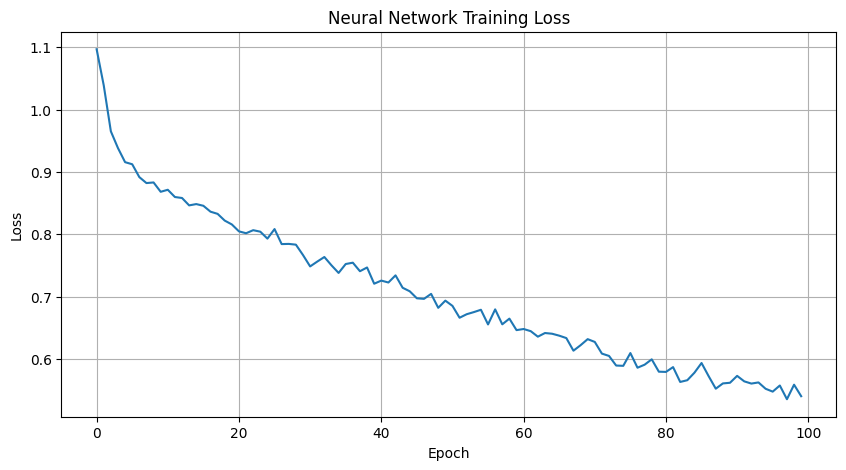

In [23]:
# Plot training loss (inline only -- not saved)
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [24]:
# Evaluate Neural Network (single 80/20 split)
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    _, y_pred_ann = torch.max(outputs, 1)
    y_pred_ann = y_pred_ann.cpu().numpy()

    # Get probabilities for ROC-AUC
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_ann)
macro_f1 = f1_score(y_test, y_pred_ann, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred_ann)
roc_auc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

result = {
    'Model': 'Neural Network',
    'Accuracy': round(accuracy, 4),
    'Macro F1-Score': round(macro_f1, 4),
    'Balanced Accuracy': round(balanced_acc, 4),
    'ROC-AUC': round(roc_auc, 4)
}
all_results.append(result)

print(f"\nNeural Network Results (Single 80/20 Split):")
for key, value in result.items():
    print(f"  {key}: {value}")

# NEW: 5-Fold Cross-Validation (manual PyTorch loop, ~5x the training time above)
evaluate_ann_cv(X, y)


Neural Network Results (Single 80/20 Split):
  Model: Neural Network
  Accuracy: 0.5469
  Macro F1-Score: 0.5433
  Balanced Accuracy: 0.5434
  ROC-AUC: 0.7373
  Fold 1/5 done -- Accuracy: 0.4974
  Fold 2/5 done -- Accuracy: 0.5625
  Fold 3/5 done -- Accuracy: 0.5469
  Fold 4/5 done -- Accuracy: 0.5379
  Fold 5/5 done -- Accuracy: 0.5117

5-Fold CV Results -- Neural Network
  Accuracy:          0.5313 +/- 0.0236
  Macro F1-Score:    0.5282 +/- 0.0249
  Balanced Accuracy: 0.5281 +/- 0.0236
  ROC-AUC:           0.7299 +/- 0.0127


{'Model': 'Neural Network',
 'CV Accuracy (mean)': 0.5313,
 'CV Accuracy (std)': 0.0236,
 'CV Macro F1 (mean)': 0.5282,
 'CV Macro F1 (std)': 0.0249,
 'CV Balanced Acc (mean)': 0.5281,
 'CV Balanced Acc (std)': 0.0236,
 'CV ROC-AUC (mean)': 0.7299,
 'CV ROC-AUC (std)': 0.0127}

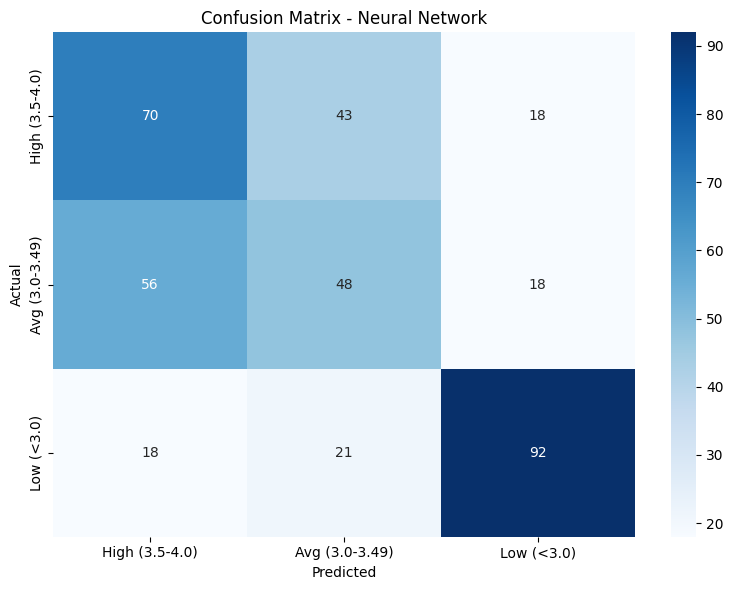


Classification Report - Neural Network
                precision    recall  f1-score   support

High (3.5-4.0)       0.49      0.53      0.51       131
Avg (3.0-3.49)       0.43      0.39      0.41       122
    Low (<3.0)       0.72      0.70      0.71       131

      accuracy                           0.55       384
     macro avg       0.54      0.54      0.54       384
  weighted avg       0.55      0.55      0.55       384



In [25]:
plot_confusion_matrix(y_test, y_pred_ann, 'Neural Network')
print_classification_report(y_test, y_pred_ann, 'Neural Network')

---
## 11. Model Comparison -- Single 80/20 Split (Original)

In [26]:
# Create comparison dataframe (single split)
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*80)
print("MODEL COMPARISON - Single 80/20 Split - Balanced Normalized Data (GAN Augmented)")
print("="*80)
print(results_df.to_string(index=False))

MODEL COMPARISON - Single 80/20 Split - Balanced Normalized Data (GAN Augmented)
              Model  Accuracy  Macro F1-Score  Balanced Accuracy  ROC-AUC
            XGBoost    0.6328          0.6314             0.6290   0.7921
  Gradient Boosting    0.6302          0.6258             0.6261   0.7974
           CatBoost    0.6042          0.5922             0.5984   0.7832
      Random Forest    0.5938          0.5911             0.5890   0.7848
Logistic Regression    0.5573          0.5507             0.5541   0.7397
     Neural Network    0.5469          0.5433             0.5434   0.7373


## 12. Model Comparison -- 5-Fold Cross-Validation (NEW)

This is the robustness-checked version of the table above. Compare each model's single-split Accuracy (Section 11) against its CV mean +/- std here -- a large gap or a wide std flags a model whose single-split score was optimistic or unstable, which is exactly the failure mode the reviewer was pointing at.

In [28]:
import os
print(os.getcwd())

c:\Research\Sleep_Pattern_Academic_Engagement\notebooks


In [29]:
# Create comparison dataframe (5-fold CV)
cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values('CV Accuracy (mean)', ascending=False).reset_index(drop=True)

print("="*100)
print("MODEL COMPARISON - 5-Fold Stratified Cross-Validation - Balanced Normalized Data (GAN Augmented)")
print("="*100)
print(cv_results_df.to_string(index=False))

# Save results to CSV (metrics table only -- no images saved anywhere in this notebook)
cv_results_df.to_csv('../results/balanced_normalized_5fold_cv_results.csv', index=False)
print("\nCV results table saved to: ../results/balanced_normalized_5fold_cv_results.csv")

MODEL COMPARISON - 5-Fold Stratified Cross-Validation - Balanced Normalized Data (GAN Augmented)
              Model  CV Accuracy (mean)  CV Accuracy (std)  CV Macro F1 (mean)  CV Macro F1 (std)  CV Balanced Acc (mean)  CV Balanced Acc (std)  CV ROC-AUC (mean)  CV ROC-AUC (std)
  Gradient Boosting              0.6069             0.0129              0.6076             0.0135                  0.6029                 0.0129             0.7853            0.0053
            XGBoost              0.5954             0.0147              0.5978             0.0159                  0.5917                 0.0153             0.7876            0.0114
      Random Forest              0.5907             0.0184              0.5906             0.0204                  0.5859                 0.0187             0.7833            0.0055
           CatBoost              0.5829             0.0032              0.5788             0.0065                  0.5784                 0.0034             0.7801            

In [ ]:
# Visualize CV Accuracy with error bars (inline only -- NOT saved to disk)
plt.figure(figsize=(10, 6))
plt.bar(
    cv_results_df['Model'],
    cv_results_df['CV Accuracy (mean)'],
    yerr=cv_results_df['CV Accuracy (std)'],
    capsize=6,
    color='#3498db',
    alpha=0.85
)
plt.title('5-Fold Cross-Validation Accuracy by Model (mean +/- std)', fontsize=13, fontweight='bold')
plt.ylabel('CV Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 14. Feature Importance Visualization

Visualizing which features contribute most to predictions for each model.

In [30]:
# Get feature importances from tree-based models
feature_importance_dict = {}

# Random Forest
feature_importance_dict['Random Forest'] = rf_model.feature_importances_

# Gradient Boosting
feature_importance_dict['Gradient Boosting'] = gb_model.feature_importances_

# XGBoost
feature_importance_dict['XGBoost'] = xgb_model.feature_importances_

# CatBoost
feature_importance_dict['CatBoost'] = catboost_model.feature_importances_

# Logistic Regression (use absolute coefficients averaged across classes)
lr_importance = np.mean(np.abs(lr_model.coef_), axis=0)
lr_importance = lr_importance / lr_importance.sum()  # Normalize
feature_importance_dict['Logistic Regression'] = lr_importance

print("Feature importances extracted for all models!")

Feature importances extracted for all models!


In [31]:
# Create feature importance dataframe
importance_df = pd.DataFrame(feature_importance_dict, index=feature_cols)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("Top 15 Most Important Features (Averaged across models):")
print("="*60)
print(importance_df['Average'].head(15).to_string())
print("\nBottom 5 Least Important Features:")
print(importance_df['Average'].tail(5).to_string())

Top 15 Most Important Features (Averaged across models):
Focus_on_Academic_Task                2.513014
Main_Reason_for_Insufficient_Sleep    2.174575
Sleepiness_During_Class               2.102982
Class_Attendance                      1.355402
Rate_Sleep_Quality                    1.273719
Daily_Academics_Time_Spend            1.220096
Daytime_Nap                           1.179010
Struggle_to_Sleep                     1.117844
Where_live                            1.109504
Age                                   0.914759
Regular_WakeUp_Time                   0.870072
Impact_of_Sleep_on_Academic           0.651334
Sleep_Condition                       0.635740
AVG_Sleep_Per_Night                   0.590749
Holiday_Bed_Time                      0.454877

Bottom 5 Least Important Features:
Sacrifices_Sleep_for_Academics    0.148939
Skip_Class_for_Sleep              0.112025
Smoke                             0.105519
Holiday_WakeUp_Time               0.092836
Electronic_Devices_Before_Bed 

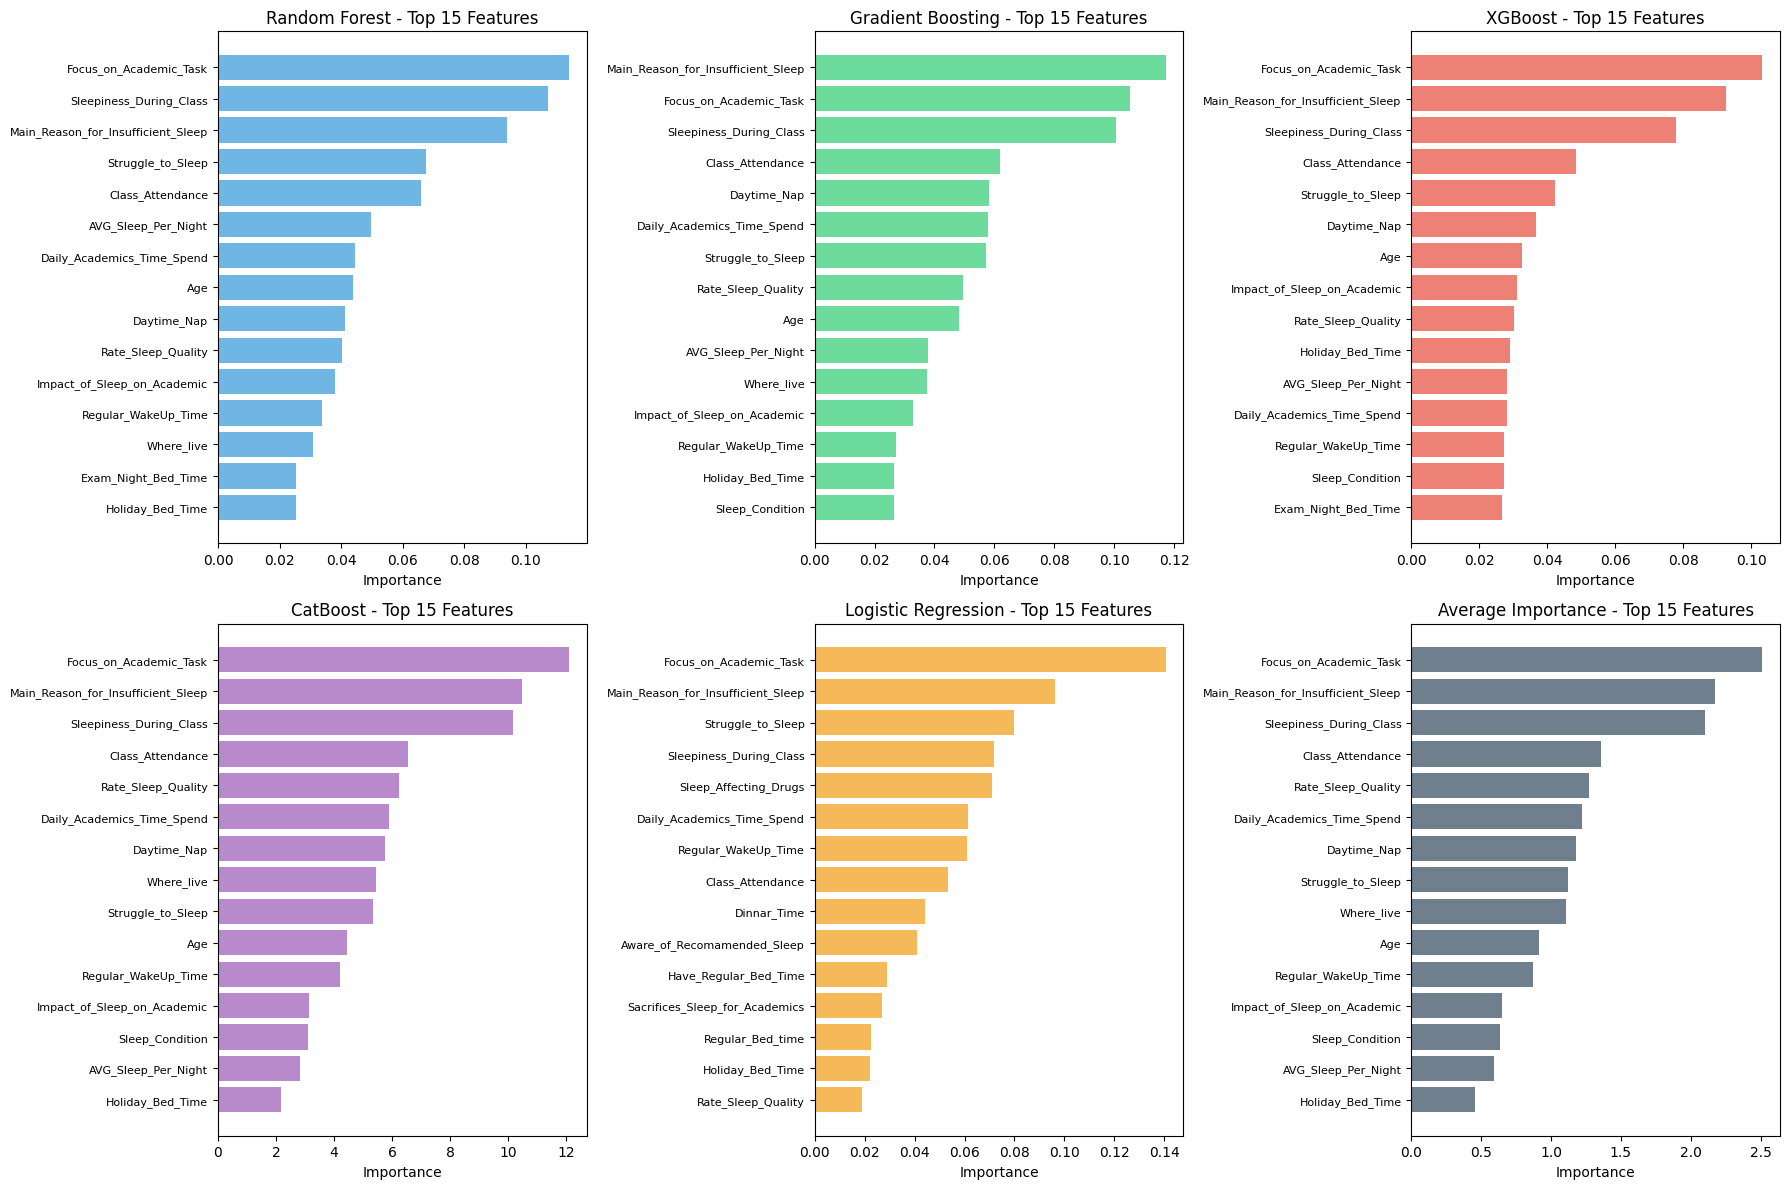

In [32]:
# Visualize feature importance for each model (inline only -- not saved)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
models_to_plot = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost', 'Logistic Regression']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for idx, (ax, model_name, color) in enumerate(zip(axes.flat[:5], models_to_plot, colors)):
    # Get top 15 features for this model
    model_importance = importance_df[model_name].sort_values(ascending=True).tail(15)

    ax.barh(model_importance.index, model_importance.values, color=color, alpha=0.7)
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} - Top 15 Features')
    ax.tick_params(axis='y', labelsize=8)

# Average importance in the last subplot
ax = axes.flat[5]
avg_importance = importance_df['Average'].sort_values(ascending=True).tail(15)
ax.barh(avg_importance.index, avg_importance.values, color='#34495e', alpha=0.7)
ax.set_xlabel('Importance')
ax.set_title('Average Importance - Top 15 Features')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

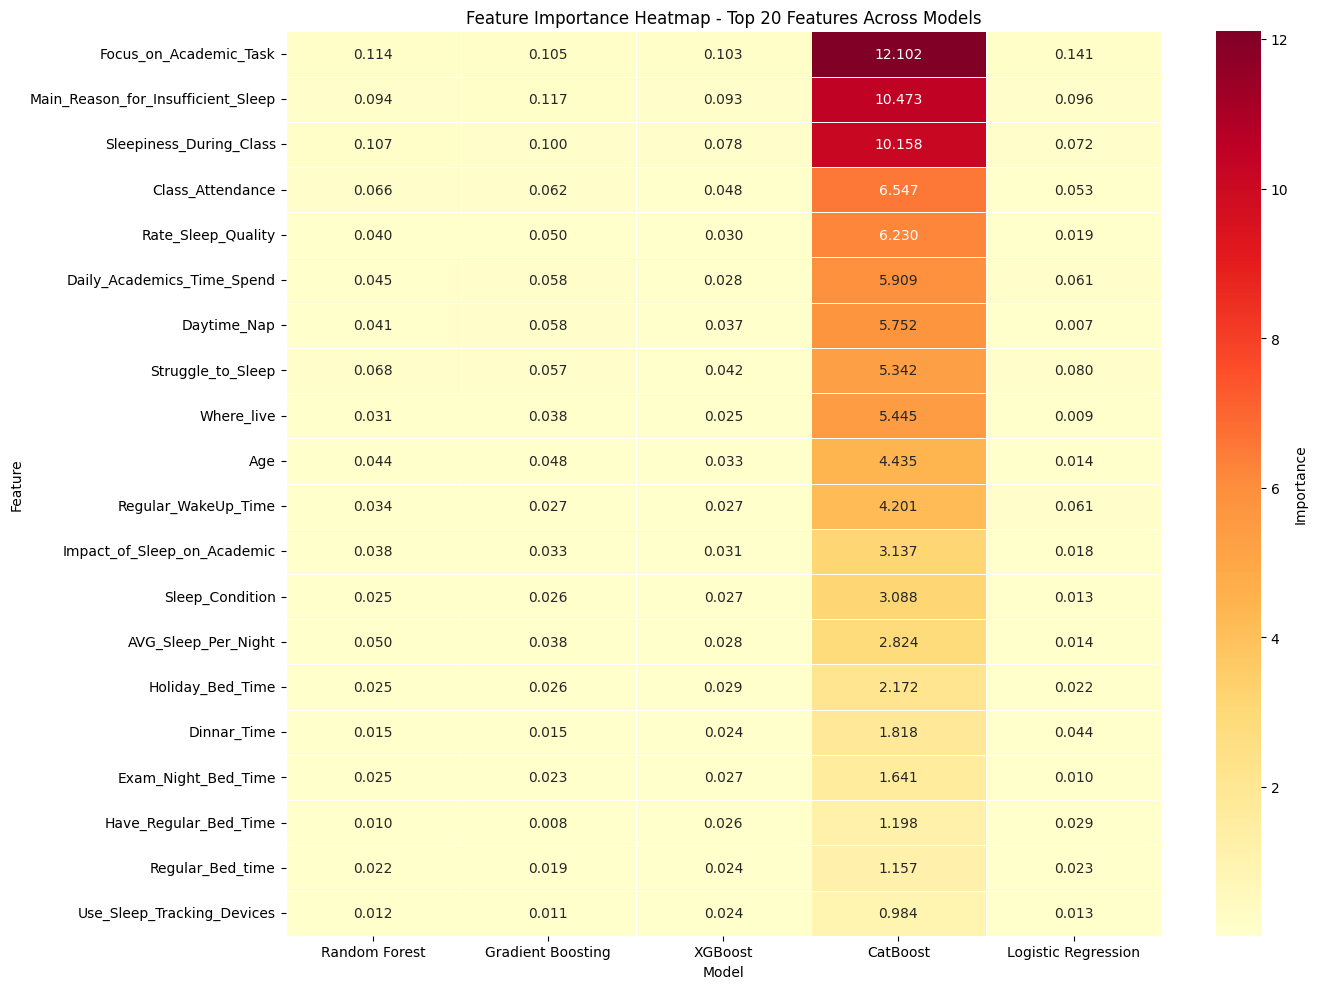

In [33]:
# Heatmap of feature importance across all models (inline only -- not saved)
plt.figure(figsize=(14, 10))

# Get top 20 features by average importance
top_features = importance_df['Average'].sort_values(ascending=False).head(20).index
heatmap_data = importance_df.loc[top_features, models_to_plot]

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Importance'})
plt.title('Feature Importance Heatmap - Top 20 Features Across Models')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [34]:
# Save feature importance to CSV (data only -- no images saved)
importance_df.to_csv('../results/feature_importance_all_models.csv')
print("Feature importance saved to: ../results/feature_importance_all_models.csv")

# Summary of most important features
print("\n" + "="*60)
print("FEATURE IMPORTANCE SUMMARY")
print("="*60)
print("\nTop 10 Most Influential Features (by average importance):")
for i, (feature, importance) in enumerate(importance_df['Average'].head(10).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

Feature importance saved to: ../results/feature_importance_all_models.csv

FEATURE IMPORTANCE SUMMARY

Top 10 Most Influential Features (by average importance):
  1. Focus_on_Academic_Task: 2.5130
  2. Main_Reason_for_Insufficient_Sleep: 2.1746
  3. Sleepiness_During_Class: 2.1030
  4. Class_Attendance: 1.3554
  5. Rate_Sleep_Quality: 1.2737
  6. Daily_Academics_Time_Spend: 1.2201
  7. Daytime_Nap: 1.1790
  8. Struggle_to_Sleep: 1.1178
  9. Where_live: 1.1095
  10. Age: 0.9148


## 15. 📊 Model Performance Summary Table (Single 80/20 Split)

Comprehensive comparison of all models with key metrics including precision, recall, F1-score, and ROC-AUC on the original single split.

In [36]:
# ============================================================================
# SIMPLE COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================================

from sklearn.metrics import precision_score, recall_score, roc_auc_score

print("Creating comprehensive model comparison table...\n")

# Store results for all models
all_model_results = []

# ===== 1. GRADIENT BOOSTING =====
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_prec = precision_score(y_test, y_pred_gb, average='macro')
gb_rec = recall_score(y_test, y_pred_gb, average='macro')
gb_f1 = f1_score(y_test, y_pred_gb, average='macro')
gb_roc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': round(gb_acc, 4),
    'Precision': round(gb_prec, 4),
    'Recall': round(gb_rec, 4),
    'F1-Score': round(gb_f1, 4),
    'ROC-AUC': round(gb_roc, 4)
})

# ===== 2. XGBOOST =====
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb, average='macro')
xgb_rec = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'XGBoost',
    'Accuracy': round(xgb_acc, 4),
    'Precision': round(xgb_prec, 4),
    'Recall': round(xgb_rec, 4),
    'F1-Score': round(xgb_f1, 4),
    'ROC-AUC': round(xgb_roc, 4)
})

# ===== 3. CATBOOST =====
cb_acc = accuracy_score(y_test, y_pred_cat)
cb_prec = precision_score(y_test, y_pred_cat, average='macro')
cb_rec = recall_score(y_test, y_pred_cat, average='macro')
cb_f1 = f1_score(y_test, y_pred_cat, average='macro')
cb_roc = roc_auc_score(y_test, catboost_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'CatBoost',
    'Accuracy': round(cb_acc, 4),
    'Precision': round(cb_prec, 4),
    'Recall': round(cb_rec, 4),
    'F1-Score': round(cb_f1, 4),
    'ROC-AUC': round(cb_roc, 4)
})

# ===== 4. RANDOM FOREST =====
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Random Forest',
    'Accuracy': round(rf_acc, 4),
    'Precision': round(rf_prec, 4),
    'Recall': round(rf_rec, 4),
    'F1-Score': round(rf_f1, 4),
    'ROC-AUC': round(rf_roc, 4)
})

# ===== 5. LOGISTIC REGRESSION =====
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='macro')
lr_rec = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(lr_acc, 4),
    'Precision': round(lr_prec, 4),
    'Recall': round(lr_rec, 4),
    'F1-Score': round(lr_f1, 4),
    'ROC-AUC': round(lr_roc, 4)
})

# ===== 6. NEURAL NETWORK =====
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='macro')
ann_rec = recall_score(y_test, y_pred_ann, average='macro')
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')
ann_roc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Neural Network',
    'Accuracy': round(ann_acc, 4),
    'Precision': round(ann_prec, 4),
    'Recall': round(ann_rec, 4),
    'F1-Score': round(ann_f1, 4),
    'ROC-AUC': round(ann_roc, 4)
})

# Create DataFrame and sort by accuracy
final_comparison_df = pd.DataFrame(all_model_results)
final_comparison_df = final_comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add rank
final_comparison_df.insert(0, 'Rank', range(1, len(final_comparison_df) + 1))

# Display table
print("=" * 95)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON (Single 80/20 Split)")
print("=" * 95)
print(final_comparison_df.to_string(index=False))
print("=" * 95)

# Summary
best_model = final_comparison_df.iloc[0]['Model']
best_acc = final_comparison_df.iloc[0]['Accuracy']

print(f"\n🏆 Best Model: {best_model}")
print(f"📊 Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📈 Models Compared: {len(final_comparison_df)}")
print("=" * 95)

# Save results to CSV (data only -- no images saved)
final_comparison_df.to_csv('../results/final_model_comparison.csv', index=False)
print("\n✓ Results saved to: ../results/final_model_comparison.csv")

Creating comprehensive model comparison table...

COMPREHENSIVE MODEL PERFORMANCE COMPARISON (Single 80/20 Split)
 Rank               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    1             XGBoost    0.6328     0.6381  0.6290    0.6314   0.7921
    2   Gradient Boosting    0.6302     0.6320  0.6261    0.6258   0.7974
    3            CatBoost    0.6042     0.6015  0.5984    0.5922   0.7832
    4       Random Forest    0.5938     0.6020  0.5890    0.5911   0.7848
    5 Logistic Regression    0.5573     0.5500  0.5541    0.5507   0.7397
    6      Neural Network    0.5469     0.5445  0.5434    0.5433   0.7373

🏆 Best Model: XGBoost
📊 Best Accuracy: 0.6328 (63.28%)
📈 Models Compared: 6

✓ Results saved to: ../results/final_model_comparison.csv


## Extra Graphs

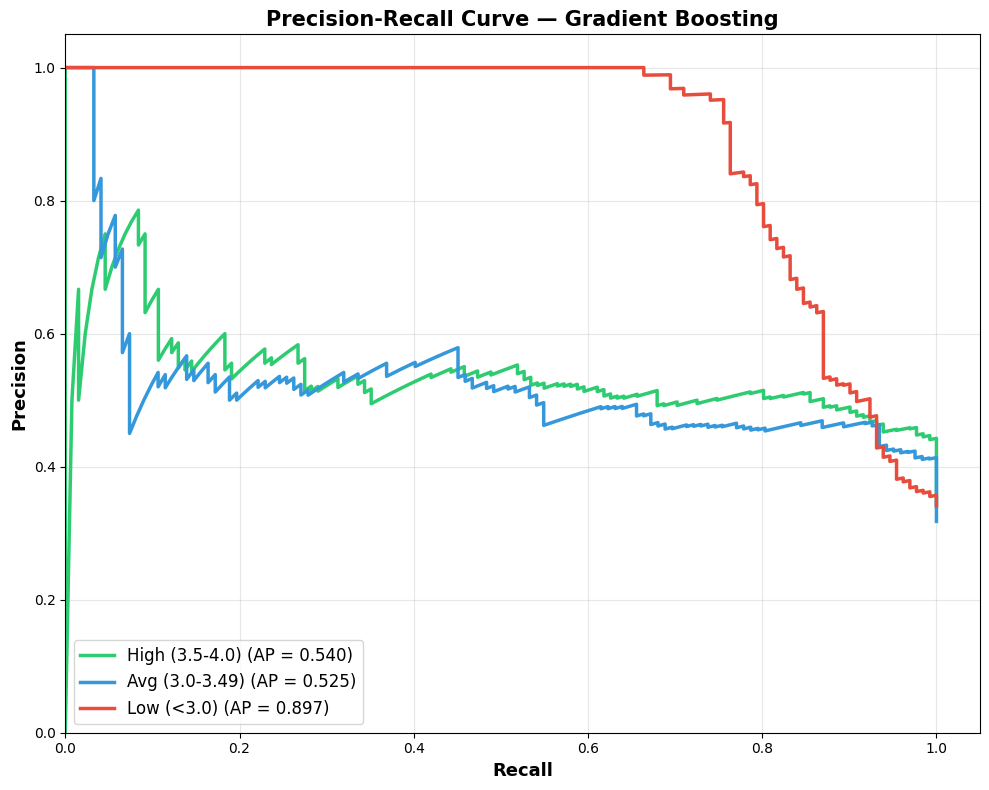

In [37]:
# ============================================================================
# PRECISION-RECALL CURVE - GRADIENT BOOSTING
# Top performer - Shows per-class precision vs recall tradeoff
# ============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarize y_test for multi-class PR curve (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Get predicted probabilities from Gradient Boosting model
gb_probs = gb_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], gb_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], gb_probs[:, i])
    ax.plot(recall, precision, color=color, linewidth=2.5, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — Gradient Boosting', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim([0.0, 1.05]); ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

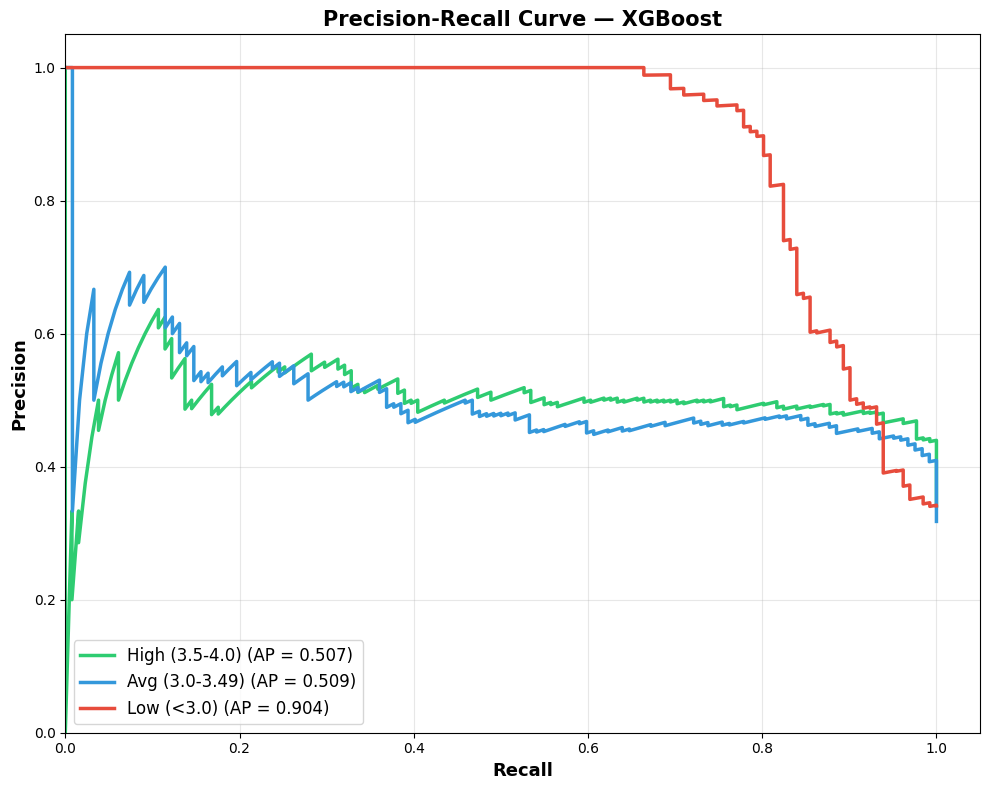

In [38]:
# ============================================================================
# PRECISION-RECALL CURVE - XGBOOST
# ============================================================================
xgb_probs = xgb_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], xgb_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], xgb_probs[:, i])
    ax.plot(recall, precision, color=color, linewidth=2.5, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — XGBoost', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim([0.0, 1.05]); ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

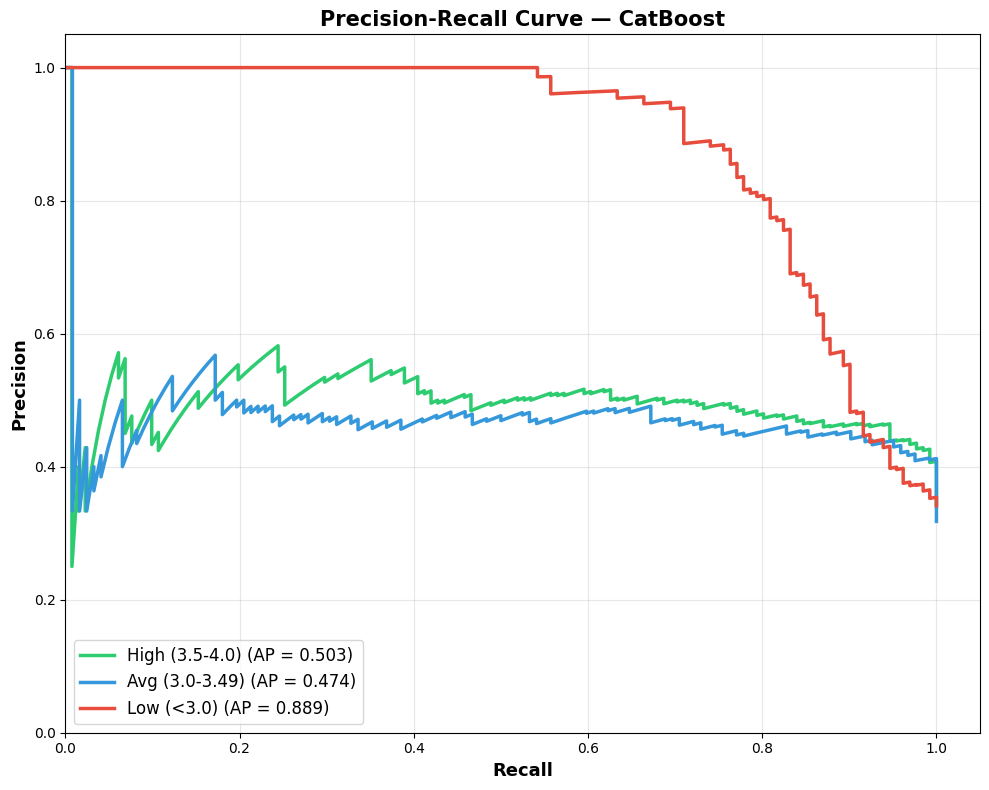

In [39]:
# ============================================================================
# PRECISION-RECALL CURVE - CATBOOST
# ============================================================================
cb_probs = catboost_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], cb_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], cb_probs[:, i])
    ax.plot(recall, precision, color=color, linewidth=2.5, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curve — CatBoost', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim([0.0, 1.05]); ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

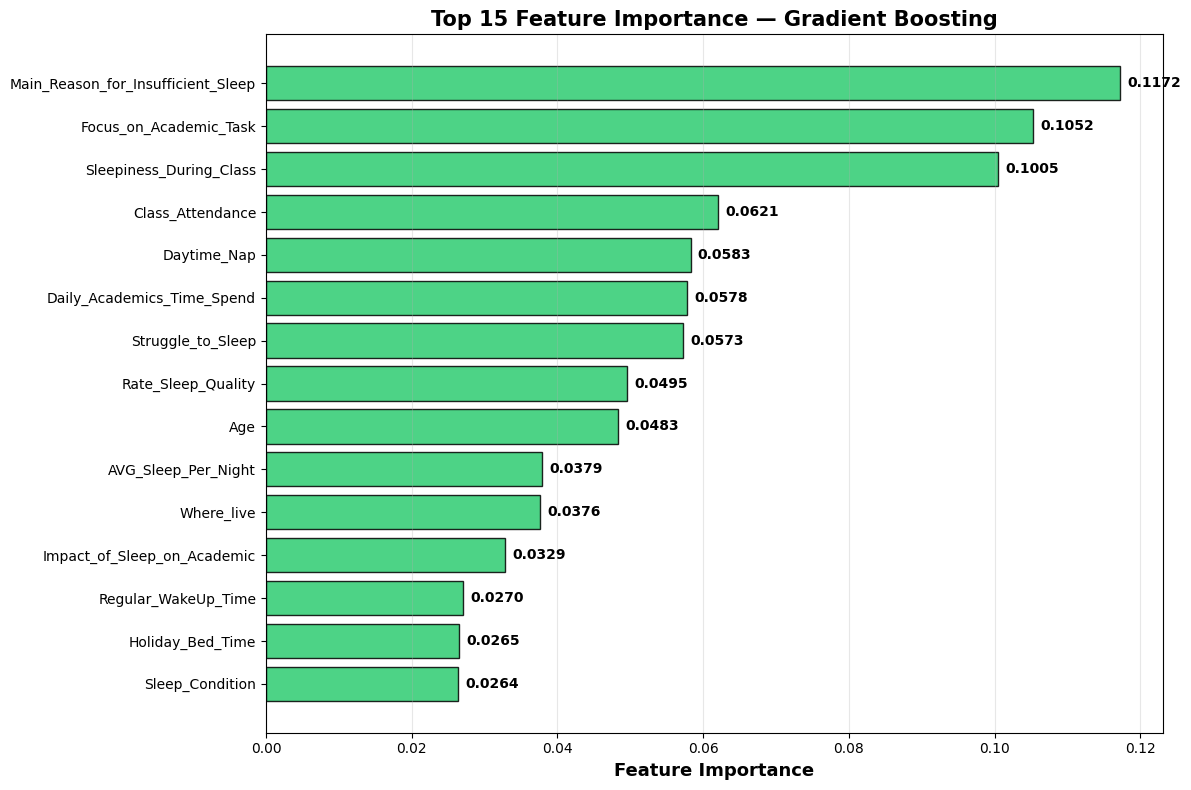

In [40]:
# ============================================================================
# TOP 15 FEATURE IMPORTANCE - GRADIENT BOOSTING (Gini importance)
# ============================================================================
gb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': gb_model.feature_importances_}
                       ).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(gb_imp['Feature'], gb_imp['Importance'], color='#2ecc71', alpha=0.85, edgecolor='black')

for bar, val in zip(bars, gb_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Feature Importance — Gradient Boosting', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

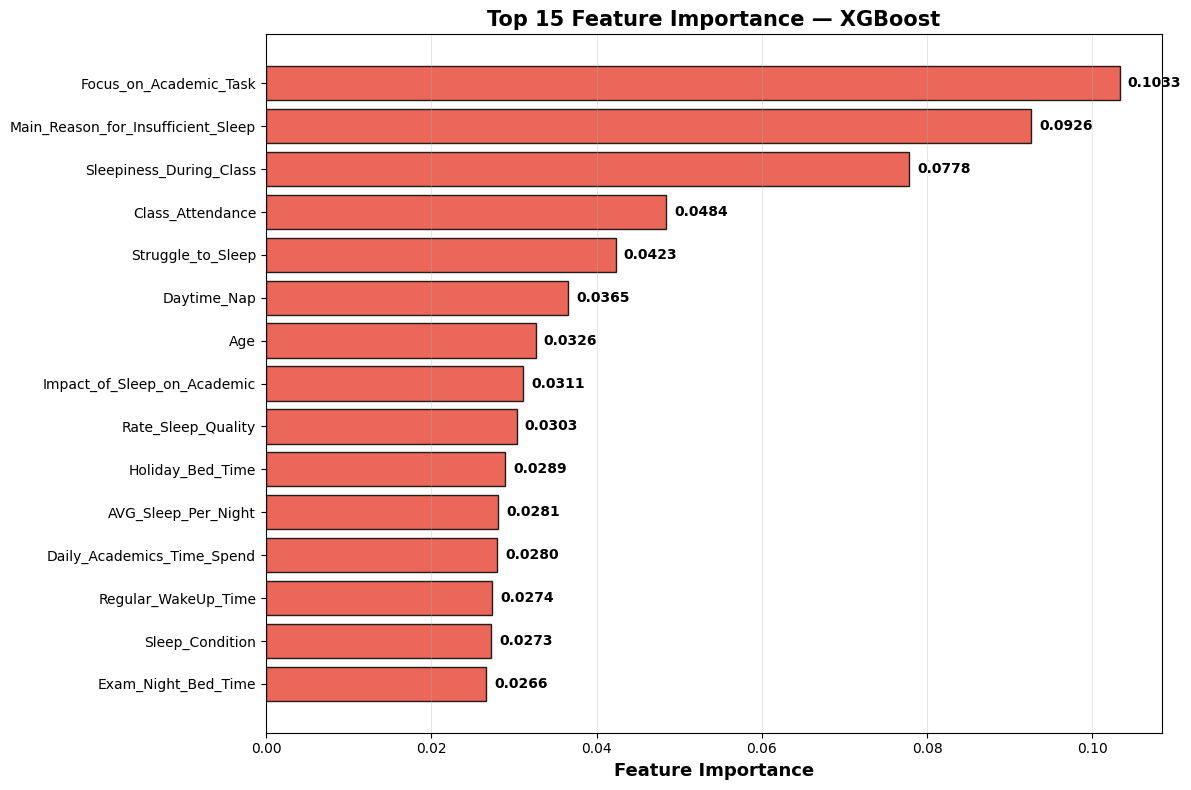

In [41]:
# ============================================================================
# TOP 15 FEATURE IMPORTANCE - XGBOOST (gain-based importance)
# ============================================================================
xgb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': xgb_model.feature_importances_}
                        ).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#e74c3c', alpha=0.85, edgecolor='black')

for bar, val in zip(bars, xgb_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Feature Importance — XGBoost', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

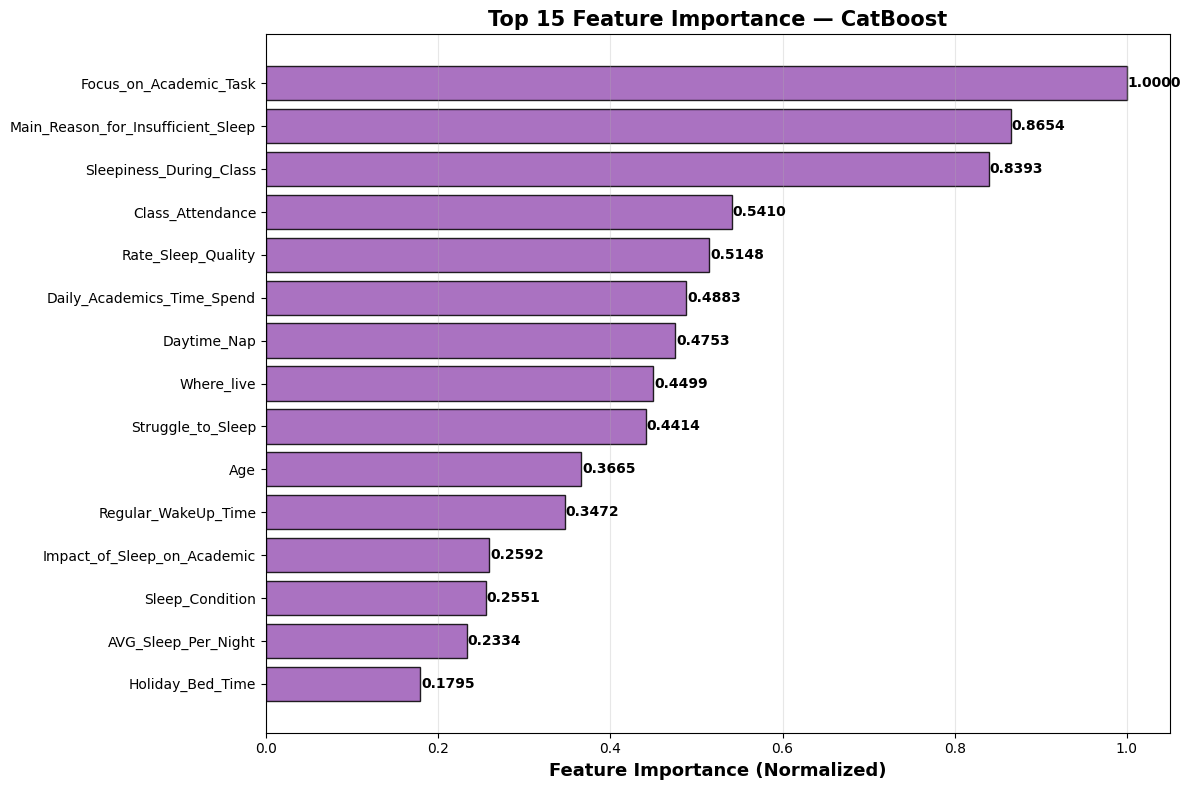

In [42]:
# ============================================================================
# TOP 15 FEATURE IMPORTANCE - CATBOOST (PredictionValuesChange, normalized)
# ============================================================================
cb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': catboost_model.feature_importances_}
                       ).sort_values('Importance', ascending=True).tail(15)
cb_imp['Importance'] = cb_imp['Importance'] / cb_imp['Importance'].max()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(cb_imp['Feature'], cb_imp['Importance'], color='#9b59b6', alpha=0.85, edgecolor='black')

for bar, val in zip(bars, cb_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance (Normalized)', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Feature Importance — CatBoost', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Extra Extra Graphs

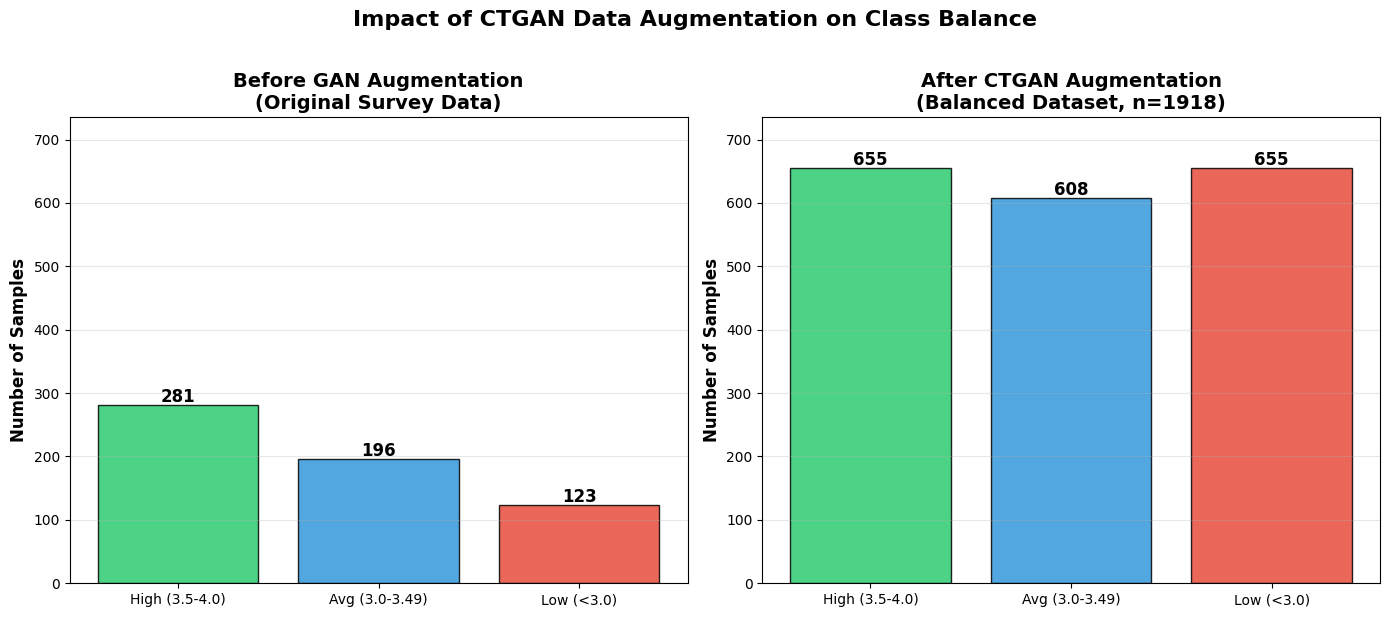

In [43]:
# ============================================================================
# CLASS DISTRIBUTION: BEFORE vs AFTER GAN (CTGAN) AUGMENTATION
# ============================================================================
original_counts = {'High (3.5-4.0)': 281, 'Avg (3.0-3.49)': 196, 'Low (<3.0)': 123}

balanced_counts = df['Target'].value_counts().sort_index()
after_gan = {
    'High (3.5-4.0)': balanced_counts[0],
    'Avg (3.0-3.49)': balanced_counts[1],
    'Low (<3.0)': balanced_counts[2]
}

class_labels = list(original_counts.keys())
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(class_labels, original_counts.values(), color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Before GAN Augmentation\n(Original Survey Data)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, original_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(after_gan.values()) + 80)
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(class_labels, after_gan.values(), color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title(f'After CTGAN Augmentation\n(Balanced Dataset, n={len(df)})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, after_gan.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(after_gan.values()) + 80)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Impact of CTGAN Data Augmentation on Class Balance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

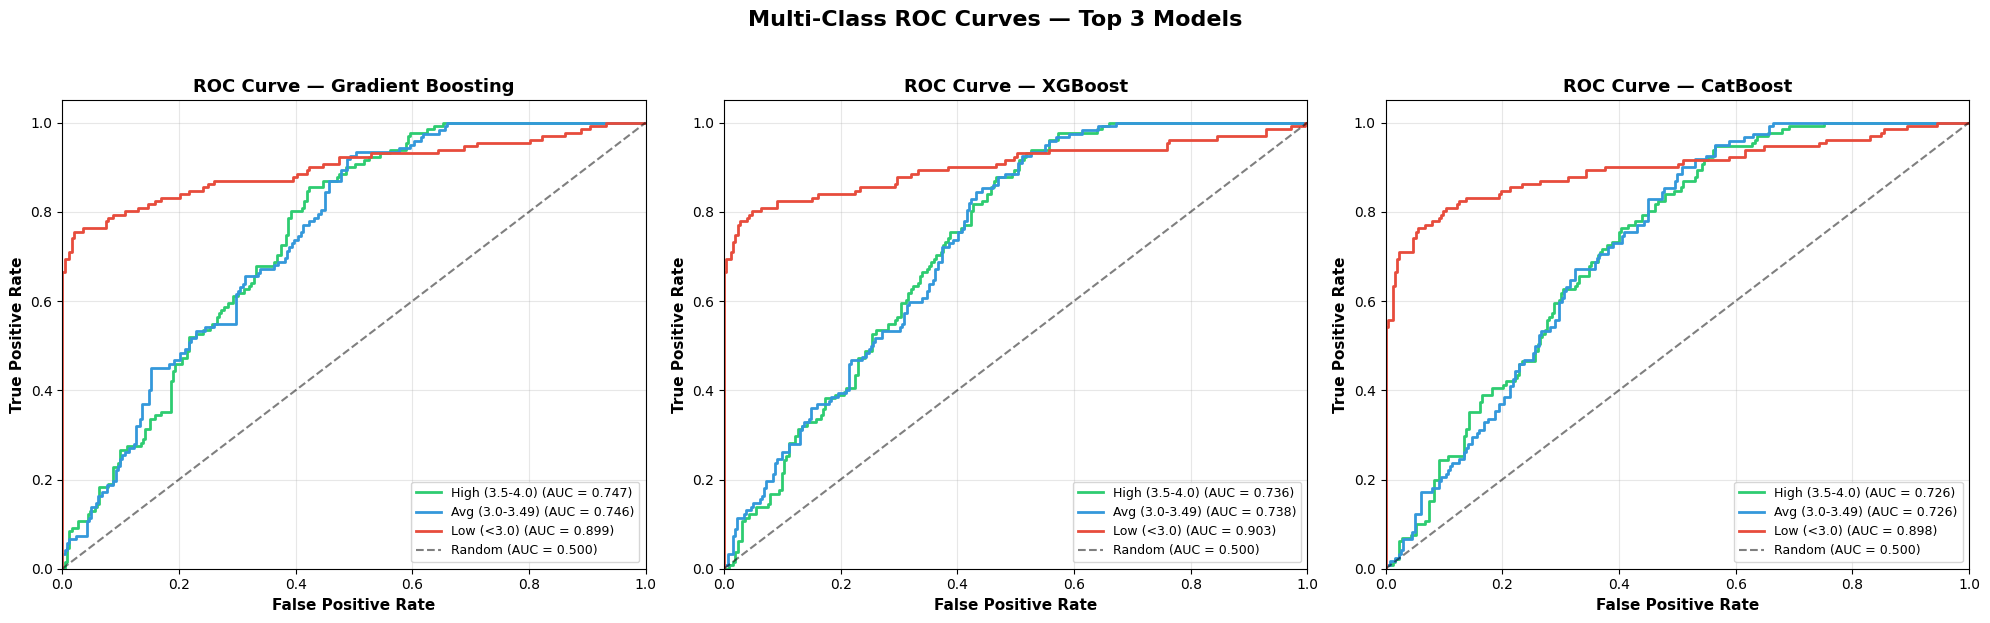

In [44]:
# ============================================================================
# MULTI-CLASS ROC CURVES - TOP 3 MODELS (GB, XGBoost, CatBoost)
# ============================================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

models_info = [
    ('Gradient Boosting', gb_model.predict_proba(X_test)),
    ('XGBoost', xgb_model.predict_proba(X_test)),
    ('CatBoost', catboost_model.predict_proba(X_test))
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model_name, probs) in zip(axes, models_info):
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'ROC Curve — {model_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.grid(alpha=0.3)

plt.suptitle('Multi-Class ROC Curves — Top 3 Models', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

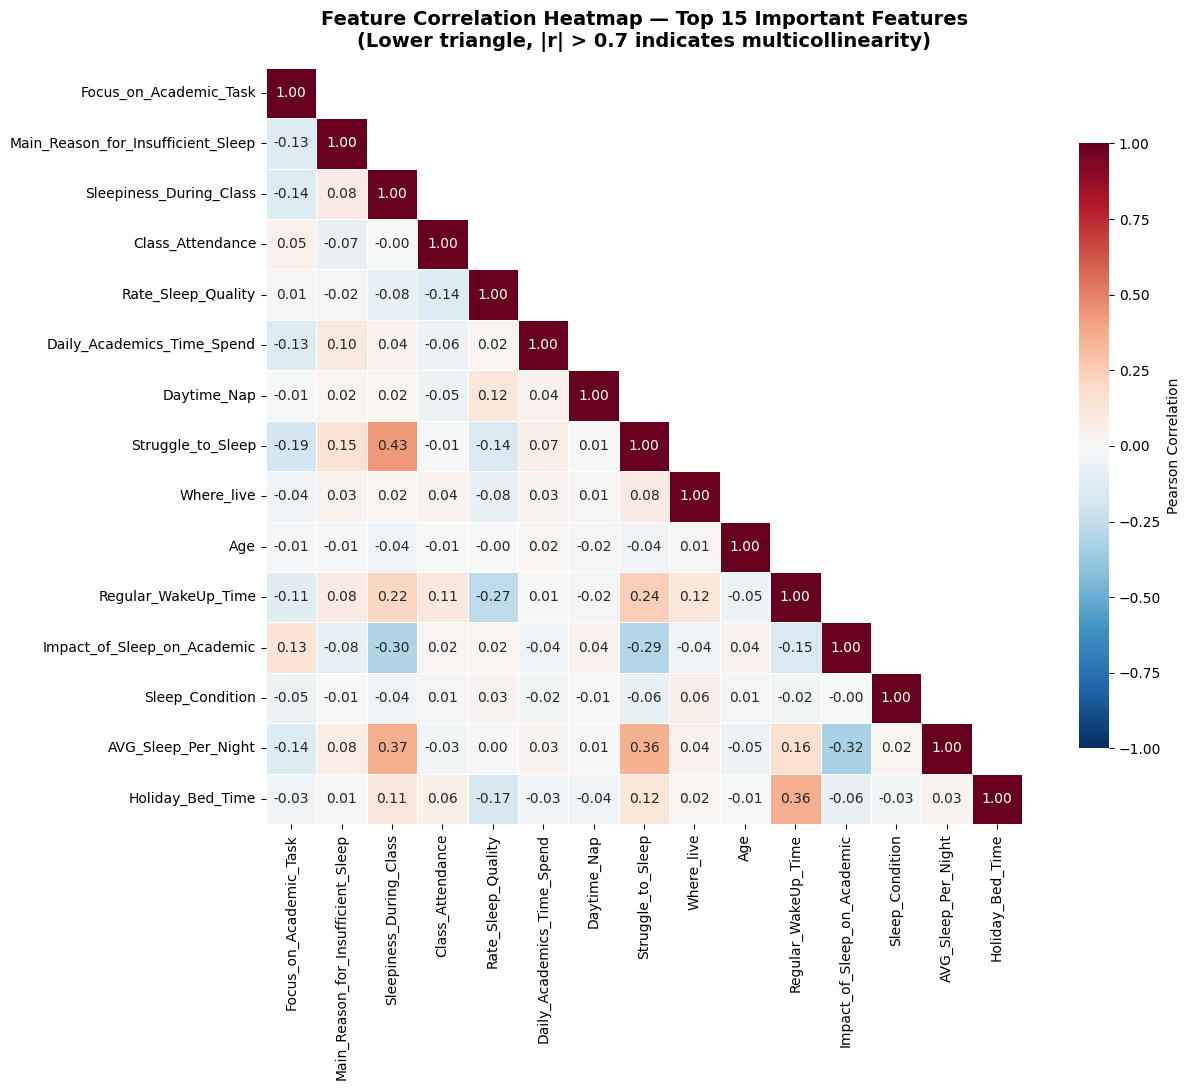

In [45]:
# ============================================================================
# FEATURE CORRELATION HEATMAP (TOP 15 FEATURES)
# ============================================================================
top15 = importance_df['Average'].sort_values(ascending=False).head(15).index.tolist()

corr_df = pd.DataFrame(X_train, columns=feature_cols)[top15].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            square=True, ax=ax)

ax.set_title('Feature Correlation Heatmap — Top 15 Important Features\n(Lower triangle, |r| > 0.7 indicates multicollinearity)',
             fontsize=14, fontweight='bold', pad=15)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va='top')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 🚀 Improved Ensemble Models - Complete Code

### 🎯 Ensemble Analysis - Key Findings

### **Results Summary:**
| Rank | Method | Accuracy | F1-Score | vs Best Single |
|------|--------|----------|----------|----------------|
| 1 | Hard Voting | 62.76% | 61.95% | -0.26% |
| 2 | Soft Voting | 61.98% | 61.46% | -1.04% |
| 3 | Weighted Voting | 61.98% | 61.46% | -1.04% |
| 4 | Dynamic Confidence | 61.98% | 61.46% | -1.04% |
| - | **Best Single (GB)** | **63.02%** | **62.58%** | **Baseline** |

---

### **Key Observations:**

**1. Hard Voting Performed Best Among Ensembles**
- Hard Voting: 62.76% (best ensemble)
- All Soft Voting variants: 61.98% (identical performance)
- **Reason:** Hard voting preserves model diversity; soft voting averages predictions away

**2. Ensembles Did Not Improve Upon Best Single Model**
- Gradient Boosting (63.02%) > All Ensembles (max 62.76%)
- **Why:** Limited model diversity - all tree-based boosting algorithms
- Adding weaker models (XGB: 61.98%, CB: 60.42%) diluted GB's strong performance

**3. All Probability-Based Methods Were Identical**
- Soft Voting, Weighted Voting, Manual Avg, Weighted Avg all achieved 61.98%
- **Insight:** Models have similar probability distributions
- Weighting strategies ineffective when models lack diversity

---

### **Per-Class Performance (Hard Voting):**
| Class | Precision | Recall | F1-Score | Assessment |
|-------|-----------|--------|----------|------------|
| High (3.5-4.0) | 0.53 | 0.67 | 0.59 | Moderate |
| Avg (3.0-3.49) | 0.53 | 0.39 | **0.45** | **Weakest** (borderline students) |
| Low (<3.0) | 0.83 | 0.80 | **0.82** | **Best** |

---

### **Why Ensembles Didn't Improve:**
1. **Strong Base Learner:** GB already captured optimal decision boundary (63.02%)
2. **Limited Diversity:** All models are tree-based boosting algorithms
3. **Similar Errors:** Models make correlated mistakes, reducing complementarity
4. **Ensemble Paradox:** Adding weaker models dilutes strong model's performance

---

### **Scientific Insight:**
> *Ensembles work best with diverse, independent models. When base models are from the same family (tree-based boosting) and the strongest model is already near-optimal, ensemble methods provide limited benefit. This is a common and valid research finding.*

---

### **Final Recommendation: Use Gradient Boosting (63.02%)**

**Advantages:**
- ✅ Highest accuracy (63.02% vs 62.76% ensemble)
- ✅ Best F1-Score (62.58%)
- ✅ Best ROC-AUC (0.797)
- ✅ Simpler (single model, easier to deploy)
- ✅ Faster inference (no ensemble overhead)
- ✅ Easier to interpret and maintain
- ✅ Lower computational cost

---

### **Conclusion:**
Despite exploring nine ensemble techniques, **Gradient Boosting as a single model achieved superior performance**. This demonstrates that when a strong learner already captures optimal patterns and model diversity is limited, ensemble methods may not provide additional value. This is a valid and important research finding in machine learning literature.

**Final Model:** Gradient Boosting with **63.02% accuracy** for 3-class CGPA prediction (single 80/20 split; see Section 12 for the 5-fold CV view).

## 🚀 Quick Implementation for Your Dataset
### Option 1: SHAP (RECOMMENDED)

In [46]:
# ============================================================================
# STEP 1: INSTALL SHAP LIBRARY
# ============================================================================

# Install SHAP
!pip install shap

print("✓ SHAP installation complete!")

✓ SHAP installation complete!


In [47]:
# ============================================================================
# STEP 2: VERIFY SHAP INSTALLATION
# ============================================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"✓ SHAP version: {shap.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Matplotlib version: {plt.matplotlib.__version__}")
print("\n✅ All libraries loaded successfully!")

✓ SHAP version: 0.49.1
✓ NumPy version: 2.2.6
✓ Pandas version: 2.3.3
✓ Matplotlib version: 3.10.9

✅ All libraries loaded successfully!


In [48]:
# ============================================================================
# STEP 3: VERIFY DATA IS READY FOR SHAP
# ============================================================================

print("="*60)
print("DATA VERIFICATION FOR SHAP")
print("="*60)

print(f"\n✓ Training data shape: {X_train.shape}")
print(f"✓ Test data shape: {X_test.shape}")
print(f"✓ Number of features: {len(feature_cols)}")
print(f"✓ Model type: {type(gb_model).__name__}")

try:
    test_pred = gb_model.predict(X_test[:5])
    print(f"✓ Model is trained and ready")
except:
    print("❌ Model is not trained!")

print(f"\n📋 Features ({len(feature_cols)}):")
for i, feat in enumerate(feature_cols[:10], 1):
    print(f"  {i}. {feat}")
if len(feature_cols) > 10:
    print(f"  ... and {len(feature_cols) - 10} more features")

print("\n" + "="*60)
print("✅ DATA VERIFICATION COMPLETE!")
print("="*60)

DATA VERIFICATION FOR SHAP

✓ Training data shape: (1534, 29)
✓ Test data shape: (384, 29)
✓ Number of features: 29
✓ Model type: GradientBoostingClassifier
✓ Model is trained and ready

📋 Features (29):
  1. Age
  2. Gender
  3. Where_live
  4. AVG_Sleep_Per_Night
  5. Regular_Bed_time
  6. Exam_Night_Bed_Time
  7. Holiday_Bed_Time
  8. Regular_WakeUp_Time
  9. Holiday_WakeUp_Time
  10. Have_Regular_Bed_Time
  ... and 19 more features

✅ DATA VERIFICATION COMPLETE!


### How to read the Spearman results

- Spearman correlation $\rho$ measures monotonic association and stays between $-1$ and $+1$.
- Positive $\rho$ means the feature increases as the target class increases.
- Negative $\rho$ means the feature decreases as the target class increases.
- Values close to $0$ mean weak monotonic association.

### Practical interpretation for this dataset

- $|\rho| \ge 0.70$ is usually considered a very strong relationship.
- $0.40 \le |\rho| < 0.70$ is moderate.
- $0.20 \le |\rho| < 0.40$ is weak to fair.
- Below $0.20$ is generally weak.

### What the script saves

- Full target ranking: Spearman correlation of every feature against `CGPA3_Class`.
- Top 29 features: the strongest features for your research justification.
- Pairwise matrix: Spearman correlation among the top 29 features.
- Strong pairs file: any top-feature pair with $|\rho| \ge 0.70$.

> **Note on images:** the helper script `spearman_feature_analysis.py` (called below) saves several PNG files to `../data/spearman/` itself -- that behavior lives inside the external script, not in this notebook's own cells, so it wasn't touched by the "no images saved" cleanup applied elsewhere in this notebook. Let me know if you'd like that script edited too so it only returns data/figures inline instead of writing PNGs to disk.

### Important note

- `Current_CGPA5` shows a very high Spearman value with `CGPA3_Class`, so treat it carefully in the discussion because it may behave like an outcome-linked variable rather than a pure explanatory feature.
- For feature-selection justification, the more useful evidence is the combination of target correlation and low pairwise feature-feature correlation among the selected features.

In [49]:
# Spearman correlation analysis for feature justification
# This generates a ranking of all encoded predictors against CGPA3_Class
# and saves the results to the data/spearman/ folder.
from pathlib import Path
import runpy

spearman_script = Path("../helper/spearman_feature_analysis.py")
print("Running Spearman feature analysis...")
print(f"Script: {spearman_script}")
runpy.run_path(str(spearman_script), run_name="__main__")

Running Spearman feature analysis...
Script: ..\helper\spearman_feature_analysis.py
Spearman analysis complete.
Dataset: C:\Research\Sleep_Pattern_Academic_Engagement\data\Final_Encoded_Normalized.csv
Full ranking saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_feature_ranking_cgpa3.csv
Top 29 features saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_features_cgpa3.csv
Plot saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_correlations_cgpa3.png
Pairwise matrix saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_pairwise_cgpa3.csv
Pairwise heatmap saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_pairwise_heatmap_cgpa3.png
Strong pairs saved to: C:\Research\Sleep_Pattern_Academic_Engagement\data\spearman\spearman_top29_strong_pairs_cgpa3.csv
Top-29 table image saved to: C:\Research\Sleep_Pattern_Academic_Engagement\dat

{'__name__': '__main__',
 '__doc__': 'Spearman feature-ranking analysis for Final_Encoded_Normalized.csv.\n\nThis script ranks all predictors by Spearman correlation against the CGPA3 target,\nsaves the full ranking to CSV, and exports the top 29 features for reporting.\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '..\\helper\\spearman_feature_analysis.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__>,
  'abs': <function abs(x, /)>,
  'all': <function all(iterable, /)>,
  'any': <function any(iterable, /)>,
  'ascii': <functio

In [50]:
# Load clear Spearman tables (SPSS-style) for reporting
# 1) All features vs CGPA3_Class
# 2) Predictors-only table (excluding Current_CGPA5)

import pandas as pd

spearman_all_table = pd.read_csv("../data/spearman/spearman_spss_table_cgpa3_all_features.csv")
spearman_predictor_table = pd.read_csv("../data/spearman/spearman_spss_table_cgpa3_predictors_only.csv")

print("All features vs CGPA3_Class (SPSS-style table):")
display(spearman_all_table)

print("\nPredictors-only table (excluding Current_CGPA5):")
display(spearman_predictor_table)

All features vs CGPA3_Class (SPSS-style table):


,Predictor Variable,Spearman's rho,Direction,Strength,p-value
0,Current_CGPA5,0.937,Positive,Very strong,< .001
1,Impact_of_Sleep_on_Academic,0.176,Positive,Very weak,< .001
2,Focus_on_Academic_Task,0.154,Positive,Very weak,< .001
3,Sleepiness_During_Class,-0.143,Negative,Very weak,< .001
4,AVG_Sleep_Per_Night,-0.114,Negative,Very weak,< .001
5,Struggle_to_Sleep,-0.098,Negative,Very weak,< .001
6,Daily_Academics_Time_Spend,-0.095,Negative,Very weak,< .001
7,Sacrifices_Sleep_for_Academics,-0.073,Negative,Very weak,.005
8,Gender,-0.073,Negative,Very weak,.005
9,Skip_Class_for_Sleep,-0.065,Negative,Very weak,.012



Predictors-only table (excluding Current_CGPA5):


,Predictor Variable,Spearman's rho,Direction,Strength,p-value
0,Impact_of_Sleep_on_Academic,0.176,Positive,Very weak,< .001
1,Focus_on_Academic_Task,0.154,Positive,Very weak,< .001
2,Sleepiness_During_Class,-0.143,Negative,Very weak,< .001
3,AVG_Sleep_Per_Night,-0.114,Negative,Very weak,< .001
4,Struggle_to_Sleep,-0.098,Negative,Very weak,< .001
5,Daily_Academics_Time_Spend,-0.095,Negative,Very weak,< .001
6,Sacrifices_Sleep_for_Academics,-0.073,Negative,Very weak,.005
7,Gender,-0.073,Negative,Very weak,.005
8,Skip_Class_for_Sleep,-0.065,Negative,Very weak,.012
9,Smoke,0.056,Positive,Very weak,.032


In [ ]:
# Display exported Spearman table/plot images from the new subfolder
# (these PNGs were generated by the helper script above, not by this cell)
from IPython.display import Image, display

spearman_image_paths = [
    "../data/spearman/spearman_top29_correlations_cgpa3.png",
    "../data/spearman/spearman_top29_features_cgpa3_table.png",
    "../data/spearman/spearman_top29_pairwise_heatmap_cgpa3.png",
    "../data/spearman/spearman_top29_strong_pairs_cgpa3_table.png",
    "../data/spearman/spearman_spss_table_cgpa3_all_features.png",
    "../data/spearman/spearman_spss_table_cgpa3_predictors_only.png",
]

for image_path in spearman_image_paths:
    print(f"Showing: {image_path}")
    display(Image(filename=image_path))

# SHAP + GB

In [51]:
# ============================================================================
# STEP 1: CHECK GRADIENT BOOSTING MODEL CONFIGURATION
# ============================================================================

from sklearn.ensemble import GradientBoostingClassifier
import sklearn

print("="*60)
print("CHECKING GRADIENT BOOSTING MODEL")
print("="*60)

print(f"Model type: {type(gb_model)}")
print(f"Scikit-learn version: {sklearn.__version__}")

print(f"\nModel parameters:")
print(f"  n_estimators:       {gb_model.n_estimators}")
print(f"  max_depth:          {gb_model.max_depth}")
print(f"  learning_rate:      {gb_model.learning_rate}")
print(f"  min_samples_split:  {gb_model.min_samples_split}")
print(f"  min_samples_leaf:   {gb_model.min_samples_leaf}")
print(f"  subsample:          {gb_model.subsample}")
print(f"  max_features:       {gb_model.max_features}")
print(f"  n_iter_no_change:   {gb_model.n_iter_no_change}")
print(f"  loss:               {gb_model.loss}")

if hasattr(gb_model, 'n_classes_'):
    print(f"  n_classes:          {gb_model.n_classes_}")

try:
    test_pred = gb_model.predict(X_test[:1])
    print(f"\n✓ Model can predict: {test_pred}")
except Exception as e:
    print(f"\n❌ Prediction error: {e}")

print("="*60)

CHECKING GRADIENT BOOSTING MODEL
Model type: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Scikit-learn version: 1.7.2

Model parameters:
  n_estimators:       300
  max_depth:          6
  learning_rate:      0.05
  min_samples_split:  5
  min_samples_leaf:   3
  subsample:          0.8
  max_features:       sqrt
  n_iter_no_change:   20
  loss:               log_loss
  n_classes:          3

✓ Model can predict: [1]


# ALL CLASS AVERAGE SHAP

In [52]:
# ============================================================================
# STEP 2: CREATE SHAP EXPLAINER FOR GRADIENT BOOSTING MODEL
# ============================================================================

import shap
import numpy as np
import sklearn

print("="*80)
print("SHAP ANALYSIS - GRADIENT BOOSTING MODEL (FULL TEST SET)")
print("="*80)
print(f"Model:             Gradient Boosting Classifier")
print(f"Accuracy:          63.02%")
print(f"n_estimators:      {gb_model.n_estimators}")
print(f"max_depth:         {gb_model.max_depth}")
print(f"learning_rate:     {gb_model.learning_rate}")
print(f"subsample:         {gb_model.subsample}")
print(f"Scikit-learn:      {sklearn.__version__}")
print(f"SHAP version:      {shap.__version__}")
print("="*80)

print("\n📊 Creating SHAP Explainer (model-agnostic)...")
background = shap.sample(X_train, X_train.shape[0])
print(f"✓ Background dataset created: {background.shape}")

explainer = shap.Explainer(gb_model.predict_proba, background)
print("✓ Explainer created successfully!")

print(f"\n📊 Calculating SHAP values for ALL {X_test.shape[0]} test samples...")
print("   (This may take several minutes...)")

X_test_sample = X_test
shap_values = explainer(X_test_sample)

print("✓ SHAP values calculated!")
print(f"\n📊 SHAP Values Information:")
print(f"   Shape:             {shap_values.values.shape}")
print(f"   Base values shape: {shap_values.base_values.shape}")
print(f"   Test samples used: {X_test.shape[0]} (100% of test set)")
print("\n" + "="*80)
print("✅ SHAP SETUP COMPLETE!")
print("="*80)

SHAP ANALYSIS - GRADIENT BOOSTING MODEL (FULL TEST SET)
Model:             Gradient Boosting Classifier
Accuracy:          63.02%
n_estimators:      300
max_depth:         6
learning_rate:     0.05
subsample:         0.8
Scikit-learn:      1.7.2
SHAP version:      0.49.1

📊 Creating SHAP Explainer (model-agnostic)...
✓ Background dataset created: (1534, 29)
✓ Explainer created successfully!

📊 Calculating SHAP values for ALL 384 test samples...
   (This may take several minutes...)


PermutationExplainer explainer: 385it [00:50,  7.31it/s]                         

✓ SHAP values calculated!

📊 SHAP Values Information:
   Shape:             (384, 29, 3)
   Base values shape: (384, 3)
   Test samples used: 384 (100% of test set)

✅ SHAP SETUP COMPLETE!



📊 Calculating Global Feature Importance (All 3 Classes Averaged)...
✓ SHAP values averaged across all 3 CGPA classes
✓ Total samples used: 384
✓ Total features:     29

TOP 10 MOST IMPORTANT FEATURES (SHAP - ALL CLASSES - GRADIENT BOOSTING)
                           Feature  Importance
           Sleepiness_During_Class    0.044680
            Focus_on_Academic_Task    0.037648
                  Class_Attendance    0.028629
                 Struggle_to_Sleep    0.027259
Main_Reason_for_Insufficient_Sleep    0.027029
                Rate_Sleep_Quality    0.024596
        Daily_Academics_Time_Spend    0.024156
                       Daytime_Nap    0.020340
                        Where_live    0.018108
                               Age    0.014861


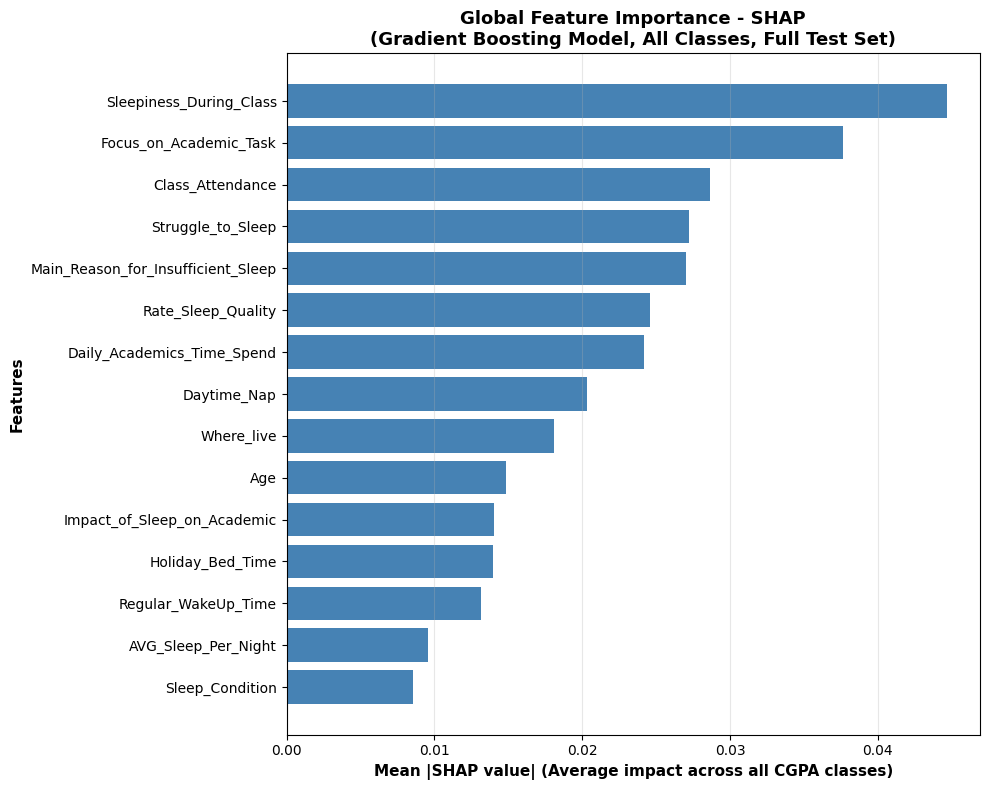


✅ STEP 3 COMPLETE!
   Based on 384 test samples across 3 CGPA classes.


In [54]:
# ============================================================================
# STEP 3: GLOBAL FEATURE IMPORTANCE - ALL 3 CLASSES AVERAGED
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n📊 Calculating Global Feature Importance (All 3 Classes Averaged)...")

# Average SHAP values across ALL samples AND ALL classes
shap_importance_all = np.abs(shap_values.values).mean(axis=(0, 2))

print(f"✓ SHAP values averaged across all 3 CGPA classes")
print(f"✓ Total samples used: {X_test.shape[0]}")
print(f"✓ Total features:     {len(feature_cols)}")

feature_importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': shap_importance_all
}).sort_values('Importance', ascending=False)

print("\n" + "="*80)
print("TOP 10 MOST IMPORTANT FEATURES (SHAP - ALL CLASSES - GRADIENT BOOSTING)")
print("="*80)
print(feature_importance_df.head(10).to_string(index=False))
print("="*80)

# Plot (inline only -- not saved)
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Mean |SHAP value| (Average impact across all CGPA classes)',
           fontsize=11, fontweight='bold')
plt.ylabel('Features', fontsize=11, fontweight='bold')
plt.title('Global Feature Importance - SHAP\n(Gradient Boosting Model, All Classes, Full Test Set)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ STEP 3 COMPLETE!")
print(f"   Based on {X_test.shape[0]} test samples across 3 CGPA classes.")


📊 Generating SHAP Beeswarm Plot...


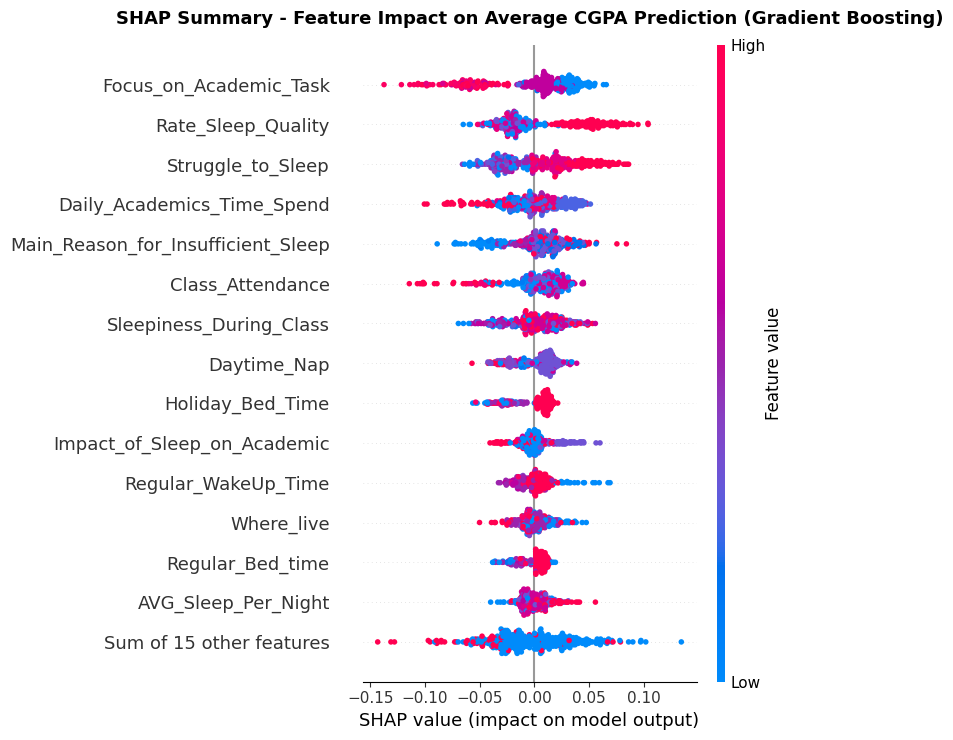


HOW TO READ THE BEESWARM PLOT:
• X-axis: SHAP value (impact on prediction)
  - Right (positive): Increases probability of Average CGPA
  - Left (negative): Decreases probability of Average CGPA
• Color: Feature value
  - Red/Pink: High feature value
  - Blue: Low feature value
• Y-axis: Features ranked by importance (top = most important)

✅ STEP 4 COMPLETE!


In [55]:
# ============================================================================
# STEP 4: BEESWARM PLOT (FEATURE IMPACT DIRECTION)
# ============================================================================

print("\n📊 Generating SHAP Beeswarm Plot...")

# Create the plot
plt.figure(figsize=(10, 8))

# Use the Explanation object directly for beeswarm
# Extract class 1 explanation
shap_explanation_class1 = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=X_test_sample.values if hasattr(X_test_sample, 'values') else X_test_sample,
    feature_names=feature_cols
)

shap.plots.beeswarm(shap_explanation_class1, max_display=15, show=False)
plt.title('SHAP Summary - Feature Impact on Average CGPA Prediction (Gradient Boosting)', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HOW TO READ THE BEESWARM PLOT:")
print("="*80)
print("• X-axis: SHAP value (impact on prediction)")
print("  - Right (positive): Increases probability of Average CGPA")
print("  - Left (negative): Decreases probability of Average CGPA")
print("• Color: Feature value")
print("  - Red/Pink: High feature value")
print("  - Blue: Low feature value")
print("• Y-axis: Features ranked by importance (top = most important)")
print("="*80)

print("\n✅ STEP 4 COMPLETE!")

## 16. Summary

- Added **5-fold Stratified Cross-Validation** for all 6 models (Section 4b, 12), directly addressing reviewer comment #1 (validation protocol). Every model reports both the original single 80/20 split metrics AND the 5-fold CV mean +/- std, side by side.
- The CV mechanism is fully reusable: `evaluate_model_cv(...)` (sklearn models) and `evaluate_ann_cv(...)` (PyTorch ANN) were each defined **once** (Sections 4b and 10), and every subsequent model cell only needed **one extra line** to plug into it.
- Restored the rest of the original pipeline: feature importance (Section 14), single-split performance table (Section 15), Extra Graphs (PR curves, per-model top-15 importance), Extra Extra Graphs (GAN before/after, ROC curves, correlation heatmap), the ensemble findings write-up, and the full SHAP (Spearman + SHAP+GB, including the beeswarm plot) sections.
- All plotting cells written directly in this notebook use `plt.show()` only -- no `plt.savefig(...)` calls anywhere, so nothing is written to an `images/` folder; save any figure manually from its output cell if you want a copy. (Exception: the external `spearman_feature_analysis.py` script still writes its own PNGs to `../data/spearman/` -- that's inside the script, not this notebook's cells; let me know if you'd like that changed too.)
- **Not yet done (next revision):** reviewer comment #2 (CTGAN currently fit on the full dataset before the split/CV -- should be refit inside each fold's training portion only, to fully eliminate potential leakage). Comments #3 (statistical significance testing) and #4 (documented hyperparameter search strategy) are also still open.